# Predicting Credit Default: Logistic Regression, Nyström SVM and JAX MLP
**Numerical Analysis for Machine Learning**

Three methods, one feature representation: regularized logistic regression,
Nyström squared-hinge SVM, and a JAX MLP. The numerical questions are how scaling,
regularization, low-rank approximation and optimization affect the result.

**Protocol:** stratified **70% Train / 15% Validation / 15% Test** per seed.
Preprocessing and kernel landmarks use training rows only. Validation selects
hyperparameters/checkpoints, fits the SVM sigmoid and chooses cost thresholds.
Its scores are selection diagnostics, not independent performance estimates.
All settings and thresholds are frozen before each split's test predictions.

Seed 42 supplies the figures. Five seeds repeat the complete selection pipeline
on their own splits: this measures combined split, initialization and landmark
sensitivity. Overlapping test sets make their mean ± sample SD descriptive,
not a confidence interval. No seed is selected for its test performance.

**Run:** Python 3.11+, install `requirements-tested.txt`, then Run All.
Place `GiveMeSomeCredit/cs-training.csv` beside the notebook, or set
`NAML_DATA_DIR` to its directory or CSV. Full grids, solver statistics and logs
go to `artifacts_focused/`; only selected configurations and final summaries
are displayed. JAX float64 remains enabled. No ensemble is fitted.


## 1. Imports and data loading

In [1]:
from pathlib import Path
from time import perf_counter
from importlib.metadata import version
import os, json, hashlib, platform, tempfile
os.environ.setdefault('MPLCONFIGDIR', str(Path(tempfile.gettempdir()) / 'naml-focused-mpl'))
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import jax
jax.config.update('jax_enable_x64', True)
import jax.numpy as jnp
from scipy.optimize import minimize
from scipy.special import expit
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics.pairwise import rbf_kernel
from sklearn.calibration import calibration_curve
from sklearn.metrics import (average_precision_score, roc_auc_score, brier_score_loss,
    log_loss, precision_recall_curve, confusion_matrix, ConfusionMatrixDisplay)
from threadpoolctl import threadpool_limits
from IPython.display import display, Markdown

SEED = 42
STUDY_SEEDS = (42, 52, 62, 72, 82)
LR_GRID = (1e-6, 1e-5, 1e-4, 1e-3, 1e-2, 1e-1)
NYSTROM_M_GRID = (64, 128, 256, 512)
NYSTROM_SCALE_GRID = (1/16, 1/4, 1.)
SVM_L2_GRID = (1e-5, 1e-4, 1e-3, 1e-2)
MLP_RATE_GRID = (3e-4, 1e-3, 3e-3)
MLP_L2_GRID = (1e-6, 1e-5, 1e-4)
COST_RATIOS = (5, 10)
SOLVER_RECORDS = []
MAX_EPOCHS, PATIENCE = 60, 8
LEARNING_RATE, MLP_L2, BATCH_SIZE = 1e-3, 1e-5, 256
MODEL_COLORS = {'Logistic Regression': '#0072B2', 'Nyström SVM': '#D55E00', 'JAX MLP': '#009E73'}
ARTIFACTS = Path(os.environ.get('NAML_OUTPUT_DIR', 'artifacts_focused'))
FIGURES = ARTIFACTS / 'figures'
FIGURES.mkdir(parents=True, exist_ok=True)
LOGS = ARTIFACTS / 'convergence_logs'
LOGS.mkdir(parents=True, exist_ok=True)
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11, 'axes.spines.top': False,
                     'axes.spines.right': False, 'axes.grid': True, 'grid.alpha': .25,
                     'pdf.fonttype': 42, 'svg.fonttype': 'none'})
def publish(fig, name):
    for extension in ('png', 'pdf', 'svg'):
        fig.savefig(FIGURES / f'{name}.{extension}', bbox_inches='tight', dpi=150)
    plt.show()
    plt.close(fig)
def save_table(table, name, show=False):
    table.to_csv(ARTIFACTS / f'{name}.csv')
    if show:
        display(table.round(6))

def flush_solver_stats():
    pd.DataFrame(SOLVER_RECORDS).to_csv(ARTIFACTS / 'solver_termination_stats.csv', index=False)

versions = {p: version(p) for p in ('numpy', 'pandas', 'scipy', 'scikit-learn',
                                     'jax', 'jaxlib', 'matplotlib', 'threadpoolctl')}
print('Python:', platform.python_version(), '| JAX devices:', jax.devices())
pd.Series(versions, name='Version').to_csv(ARTIFACTS / 'package_versions.csv')
run_started = perf_counter()

candidates = [Path('GiveMeSomeCredit/cs-training.csv'), Path('cs-training.csv')]
if location := os.environ.get('NAML_DATA_DIR'):
    p = Path(location)
    candidates.insert(0, p if p.is_file() else p / 'cs-training.csv')
csv_path = next((p for p in candidates if p.is_file()), None)
if csv_path is None:
    raise FileNotFoundError('Set NAML_DATA_DIR or place GiveMeSomeCredit/cs-training.csv beside the notebook.')
frame = pd.read_csv(csv_path, index_col=0)
target = 'SeriousDlqin2yrs'
assert len(frame) == 150_000 and frame.index.is_unique
assert frame[target].isin([0, 1]).all()
X = frame.drop(columns=target)
y = frame[target].astype(int)
def split_raw_data(seed):
    development, test, ydevelopment, ytest = train_test_split(
        X, y, test_size=22_500, stratify=y, random_state=seed)
    train, valid, ytrain, yvalid = train_test_split(
        development, ydevelopment, test_size=22_500,
        stratify=ydevelopment, random_state=seed + 1)
    groups = [set(part.index) for part in (train, valid, test)]
    assert [len(part) for part in (train, valid, test)] == [105_000, 22_500, 22_500]
    assert all(groups[i].isdisjoint(groups[j]) for i in range(3) for j in range(i))
    pd.concat([pd.Series(label, index=part.index) for label, part in
               [('Train', train), ('Validation', valid), ('Test', test)]]).rename(
                   'Split').to_csv(ARTIFACTS / f'split_ids_seed_{seed}.csv')
    return train, valid, test, ytrain, yvalid, ytest

X_train, X_val, X_test, y_train, y_val, y_test = split_raw_data(SEED)
split_table = pd.DataFrame({'Rows': [len(X_train), len(X_val), len(X_test)],
                            'Fraction': [.70, .15, .15]}, index=['Train', 'Validation', 'Test'])
save_table(split_table, 'data_split')
pd.concat([pd.Series(label, index=x.index) for label, x in
           [('Train', X_train), ('Validation', X_val), ('Test', X_test)]]).rename('Split').to_csv(ARTIFACTS / 'split_ids.csv')


Python: 3.11.14 | JAX devices: [CpuDevice(id=0)]


## 2. Data analysis and preprocessing
Explore **training rows only**. Defaults are uncommon, so accuracy alone would be
misleading: average precision (AP) summarizes the precision–recall trade-off.
Each class histogram sums to 100%, uses shared bins, and excludes missing values.
The pooled training p99 cap is for visualization only; it accumulates the upper
tail in the last bin. Correlation describes linear association, not causation.

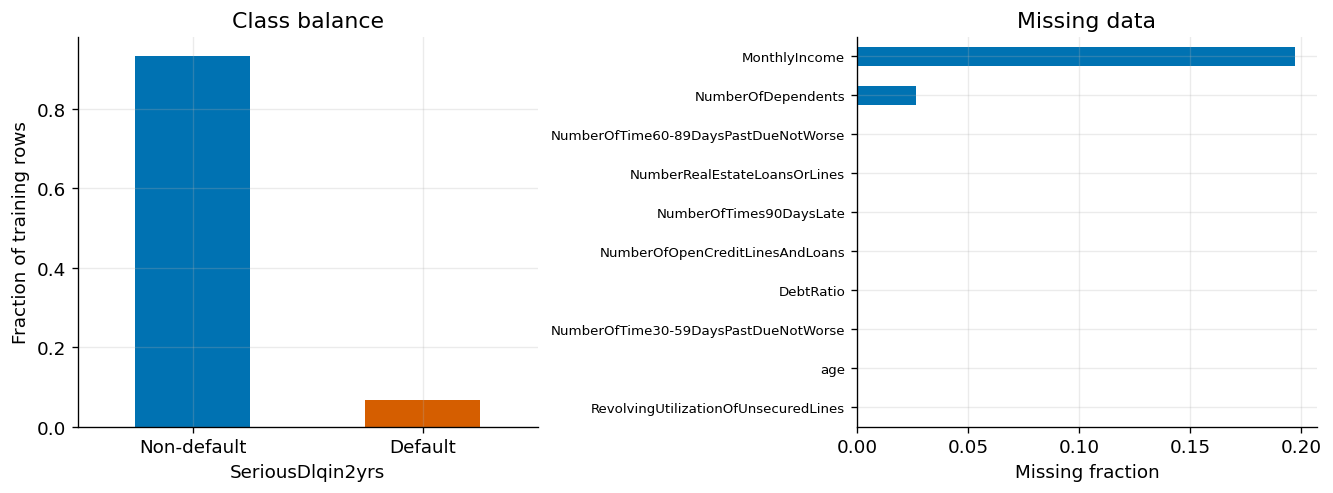

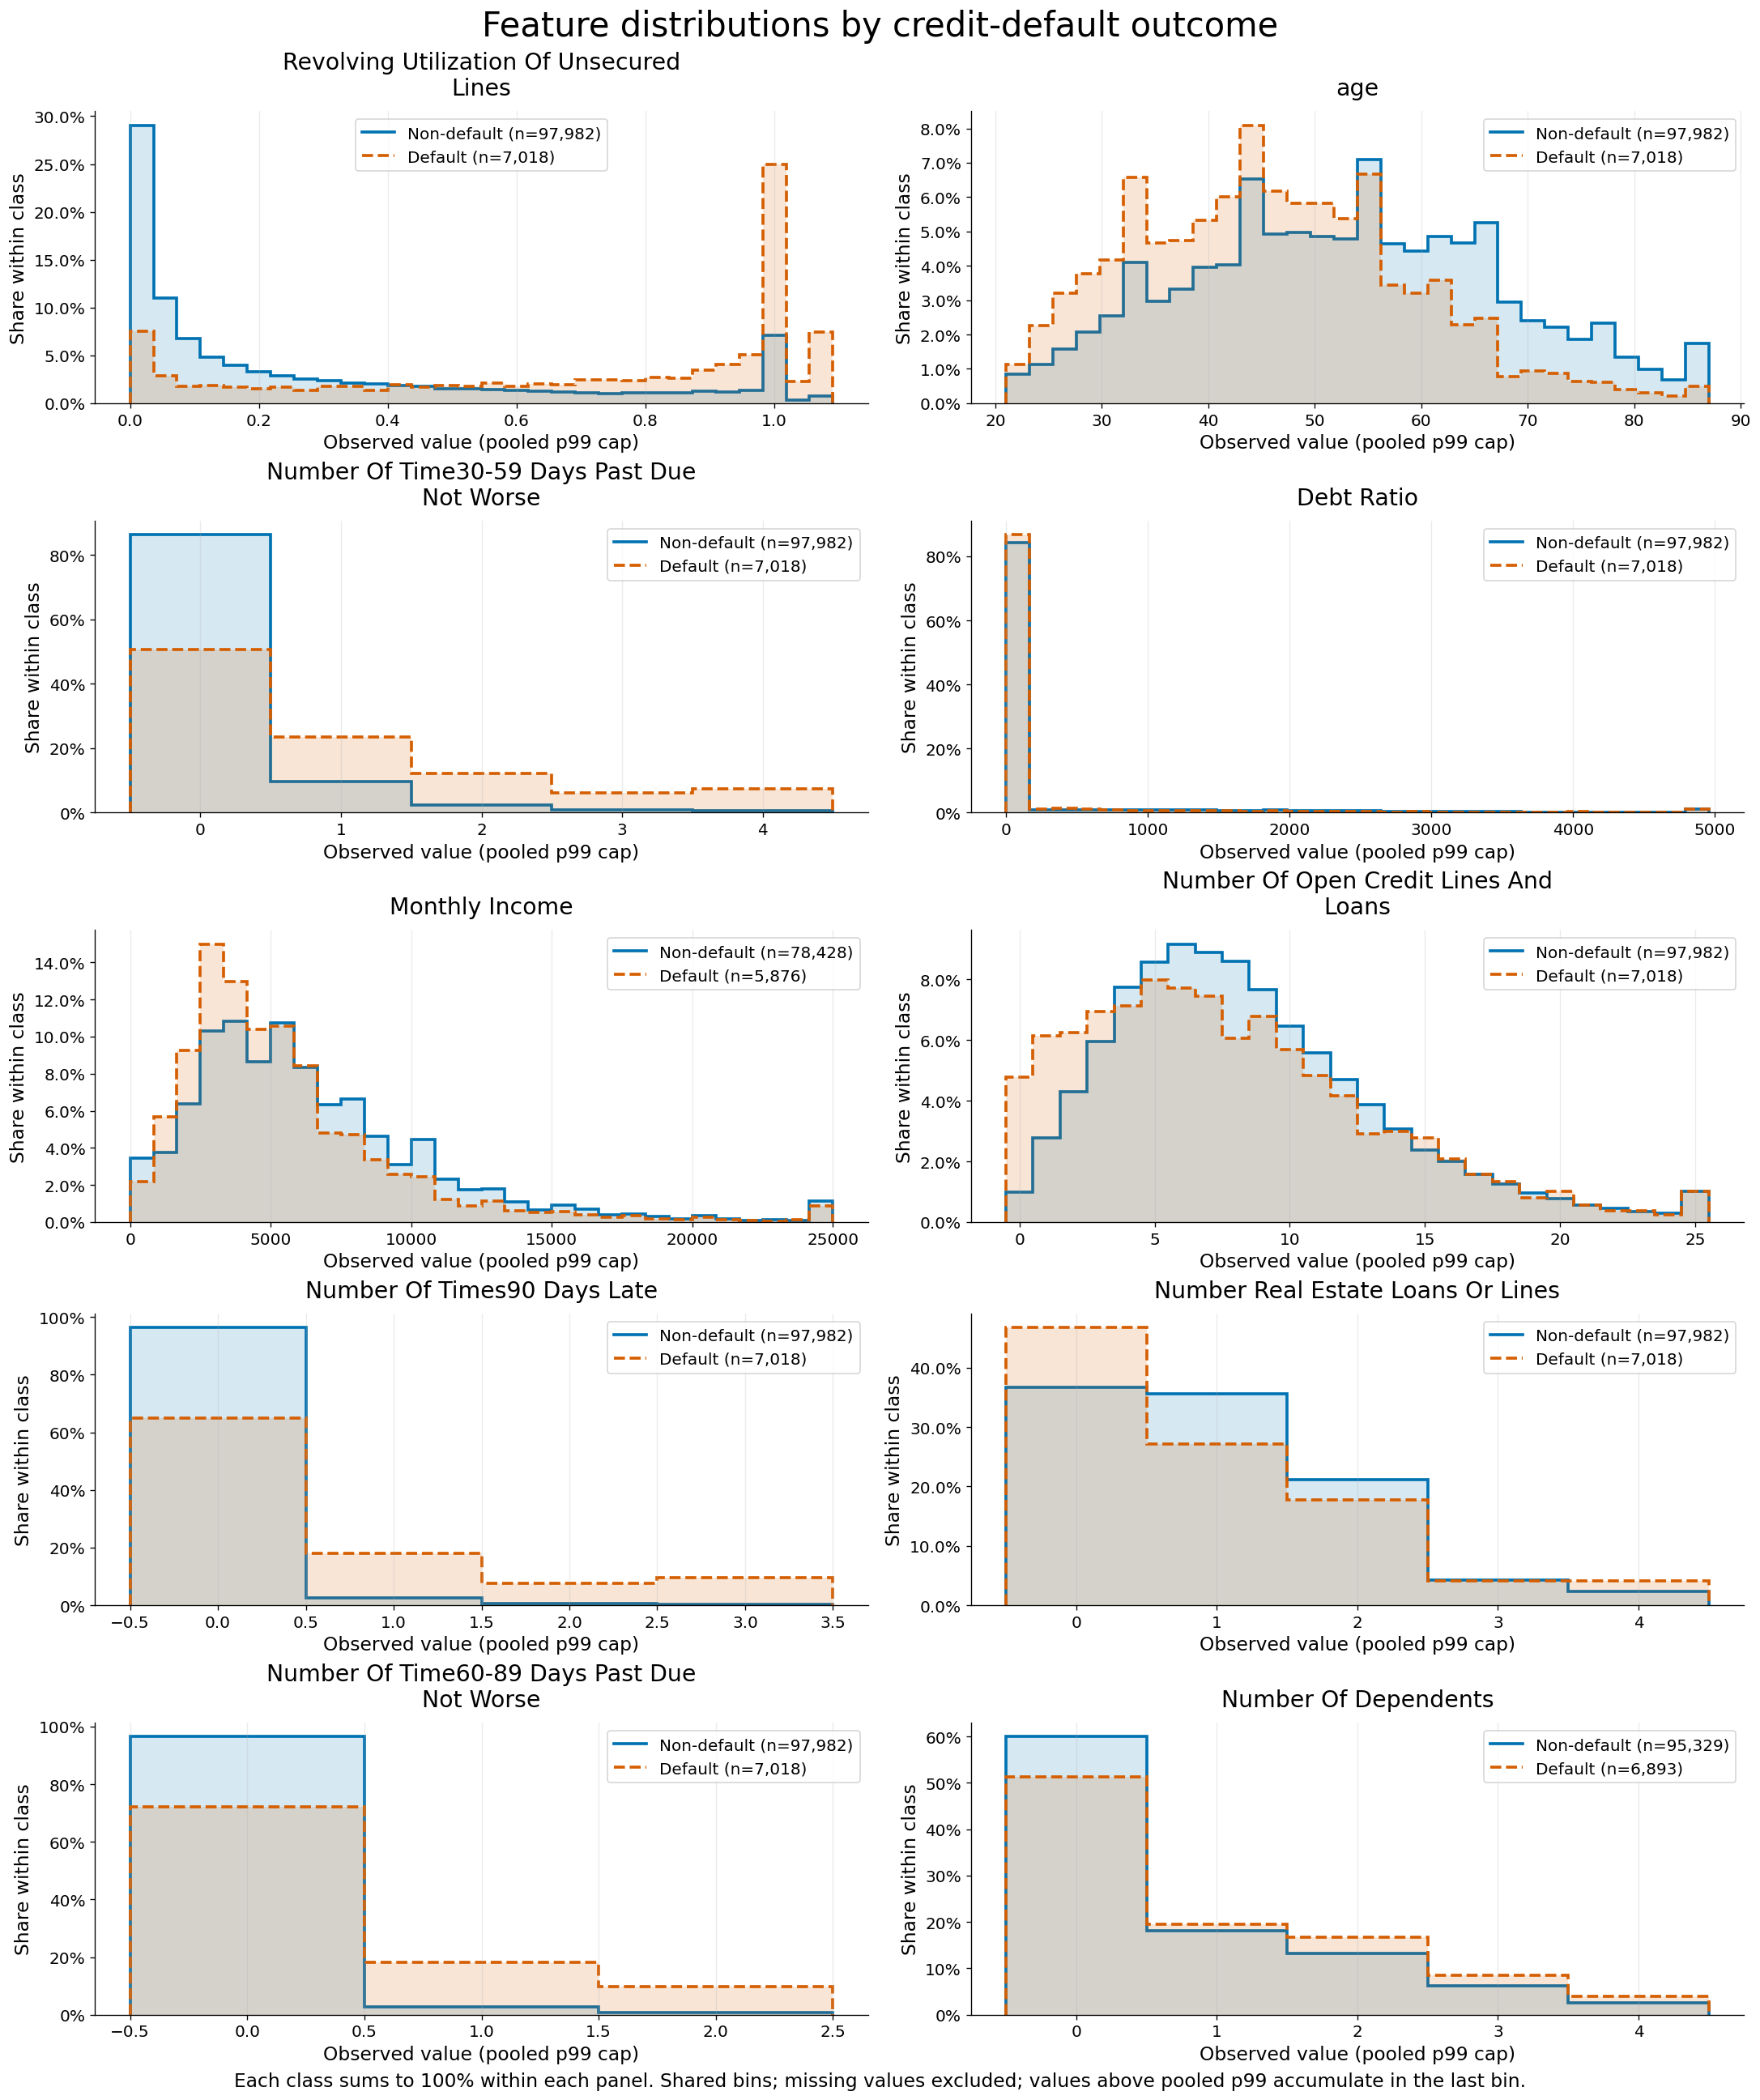

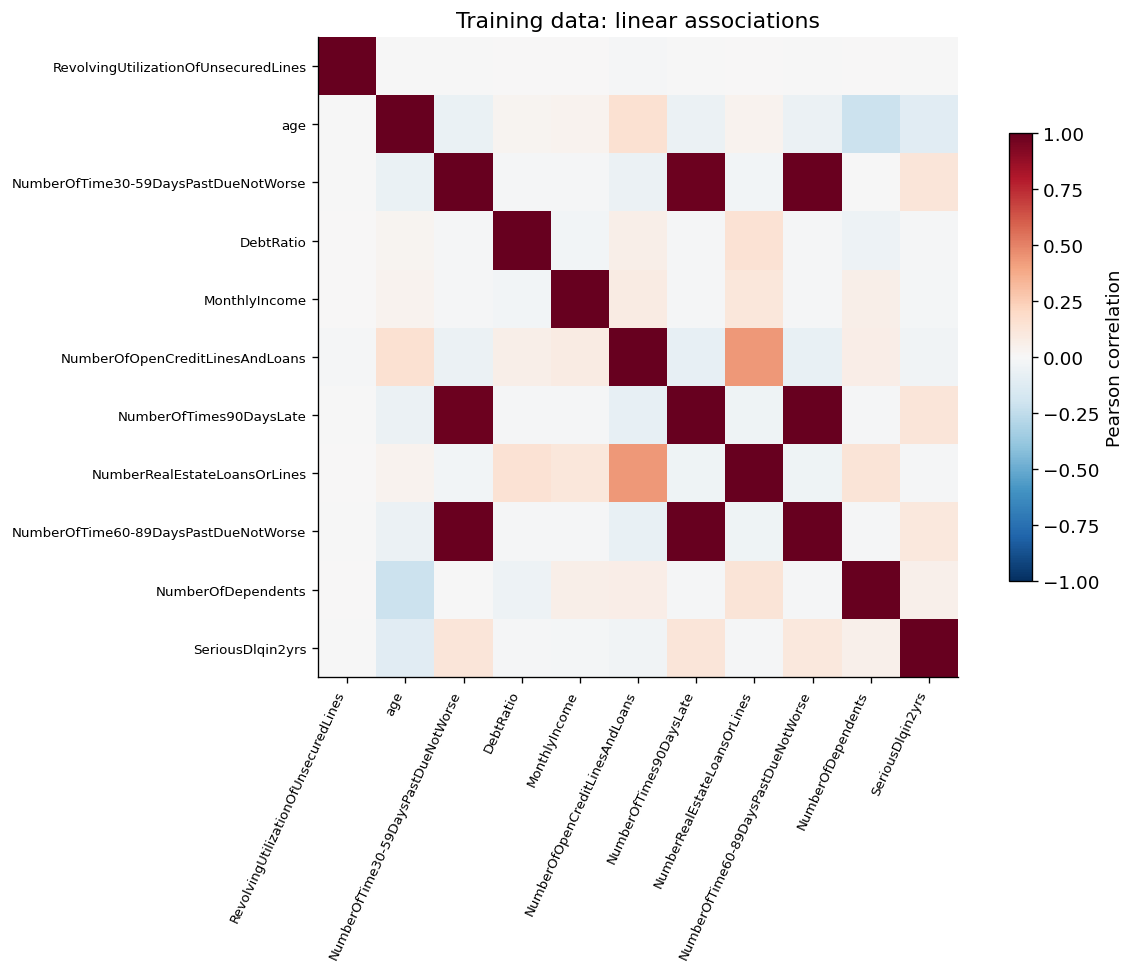

In [2]:
from matplotlib.ticker import PercentFormatter
import re
import textwrap

def plot_feature_distributions(features, labels, bins=30):
    """Shared bins and per-class unit mass; missing values excluded per feature."""
    labels = labels.reindex(features.index)
    if labels.isna().any() or not labels.isin([0, 1]).all():
        raise ValueError('Each feature row must have an aligned binary label.')
    columns = list(features.columns)
    if not columns:
        raise ValueError('At least one feature is required.')
    ncols = min(2, len(columns))
    nrows = (len(columns) + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(18, 4.3 * nrows),
                             squeeze=False, layout='constrained')
    records = []
    for ax, col in zip(axes.flat, columns):
        values = features[col].replace([np.inf, -np.inf], np.nan)
        finite = values.dropna()
        title = re.sub(r'(?<=[a-z0-9])(?=[A-Z])', ' ', col)
        title = '\n'.join(textwrap.wrap(title, width=35))
        ax.set_title(title, fontsize=17, pad=12)
        ax.set_xlabel('Observed value (pooled p99 cap)', fontsize=14)
        ax.set_ylabel('Share within class', fontsize=14)
        ax.tick_params(labelsize=12)
        ax.yaxis.set_major_formatter(PercentFormatter(xmax=1))
        ax.grid(axis='y')
        if finite.empty:
            ax.text(.5, .5, 'No observed values', ha='center', transform=ax.transAxes)
            continue
        upper = float(finite.quantile(0.99))
        clipped = values.clip(upper=upper)
        pooled = clipped.dropna().to_numpy()
        # Integer-centred bins preserve categories for small count-valued features.
        integer_values = np.allclose(pooled, np.round(pooled), rtol=0, atol=1e-10)
        if integer_values and pooled.max() - pooled.min() <= 30:
            edges = np.arange(pooled.min() - .5, pooled.max() + 1.5, 1.)
        else:
            edges = np.histogram_bin_edges(pooled, bins=bins)
        for label, name, color, style in [(0, 'Non-default', '#0072B2', '-'),
                                           (1, 'Default', '#D55E00', '--')]:
            group = clipped[labels == label].dropna().to_numpy()
            if not len(group):
                ax.plot([], [], color=color, label=f'{name}: no observed values')
                continue
            counts, _ = np.histogram(group, bins=edges)
            mass = counts / len(group)
            assert np.isclose(mass.sum(), 1.0)
            ax.stairs(mass, edges, color=color, fill=True, alpha=.16)
            ax.stairs(mass, edges, color=color, linewidth=2.2, linestyle=style,
                      label=f'{name} (n={len(group):,})')
            records.append({'Feature': col, 'Class': name, 'Observed count': len(group),
                            'Histogram mass': mass.sum(), 'Pooled p99 cap': upper,
                            'Missing/nonfinite count': int(((labels == label) & values.isna()).sum())})
        ax.legend(fontsize=12, loc='best', frameon=True)
        ax.set_ylim(bottom=0)
    for ax in list(axes.flat)[len(columns):]:
        ax.set_visible(False)
    fig.suptitle('Feature distributions by credit-default outcome', fontsize=25)
    fig.supxlabel('Each class sums to 100% within each panel. Shared bins; missing values excluded; '
                  'values above pooled p99 accumulate in the last bin.', fontsize=14)
    return fig, pd.DataFrame(records)


eda_df = X_train.join(y_train)
eda_df.describe().T.to_csv(ARTIFACTS / 'training_descriptive_statistics.csv')
fig, axes = plt.subplots(1, 2, figsize=(11, 4), layout='constrained')
y_train.value_counts(normalize=True).sort_index().plot.bar(ax=axes[0], color=['#0072B2', '#D55E00'])
axes[0].set(xticklabels=['Non-default', 'Default'], ylabel='Fraction of training rows', title='Class balance')
axes[0].tick_params(axis='x', rotation=0)
X_train.isna().mean().sort_values().plot.barh(ax=axes[1], color='#0072B2')
axes[1].set(xlabel='Missing fraction', title='Missing data')
axes[1].tick_params(axis='y', labelsize=8)
publish(fig, '01_balance_missingness')
fig, distribution_audit = plot_feature_distributions(X_train, y_train)
publish(fig, '02_feature_distributions')
distribution_audit.to_csv(ARTIFACTS / 'histogram_audit.csv', index=False)
fig, ax = plt.subplots(figsize=(10, 8), layout='constrained')
corr = eda_df.corr(numeric_only=True)
im = ax.imshow(corr, cmap='RdBu_r', vmin=-1, vmax=1)
ax.set_xticks(range(len(corr)), corr.columns, rotation=65, ha='right', fontsize=8)
ax.set_yticks(range(len(corr)), corr.columns, fontsize=8)
ax.grid(False)
fig.colorbar(im, ax=ax, label='Pearson correlation', shrink=.7)
ax.set_title('Training data: linear associations')
publish(fig, '03_correlations')


### A shared feature representation
All three models receive the same 21 standardized features. The original feature
engineering is retained to keep the model comparison focused.

| Operation | Purpose and assumption |
|---|---|
| Training medians and missingness indicators | Fill missing income/dependents without learning from validation or test rows. |
| Delinquency codes 96/98 | Flag anomalous codes, replace their counts with zero; no financial meaning is assumed. |
| Fixed clipping and `log1p` | Reduce extreme scales; age 18–100, utilization ≤10, dependents ≤10, debt ratio ≤50 are modeling choices. |
| Debt proxy and three interactions | Preserve the original hypotheses; the proxy is not verified monetary debt. |
| Standardization | Use training means and scales for every partition. |

The total delinquency count equals the sum of three component counts, creating a
linear dependency. Scaling does not remove it; L2 regularization stabilizes linear
coefficient estimation. Feature engineering can affect all model results.

In [3]:
INTERACTION_COLS = ['Debt_Per_Dependent', 'Delinquency_Intensity', 'RealEstate_Share']
BINARY_COLS = ['Special_Delinquency_Code', 'MonthlyIncome_missing', 'MonthlyIncome_zero',
               'Is_OverLimit', 'Zero_Utilization', 'NumberOfDependents_missing']

def engineer_features(frame, training_medians=None):
    out = pd.DataFrame(index=frame.index)
    late_cols = ['NumberOfTime30-59DaysPastDueNotWorse', 'NumberOfTimes90DaysLate',
                 'NumberOfTime60-89DaysPastDueNotWorse']
    out['Special_Delinquency_Code'] = frame[late_cols].isin([96, 98]).any(axis=1).astype('int8')
    for col in late_cols:
        out[col] = frame[col].replace([96, 98], np.nan).fillna(0).astype(float)
    out['Total_Past_Due'] = out[late_cols].sum(axis=1)

    income = frame['MonthlyIncome'].clip(lower=0)
    debt_ratio = frame['DebtRatio'].clip(lower=0)
    out['MonthlyIncome_missing'] = income.isna().astype('int8')
    out['MonthlyIncome_zero'] = income.eq(0).astype('int8')
    # Explicit proxy assumption for unknown/zero income; not verified dollar amounts.
    debt_proxy = debt_ratio.where(~income.gt(0), debt_ratio * income)
    out['MonthlyDebtProxy'] = np.log1p(debt_proxy)
    out['Clean_DebtRatio'] = np.log1p(debt_ratio.where(income.gt(0)).clip(0, 50))

    util = frame['RevolvingUtilizationOfUnsecuredLines'].clip(lower=0)
    out['Is_OverLimit'] = util.gt(1).astype('int8')
    out['Zero_Utilization'] = util.eq(0).astype('int8')
    out['Clean_Utilization'] = np.log1p(util.clip(upper=10))
    out['age'] = frame['age'].clip(18, 100)
    open_lines = frame['NumberOfOpenCreditLinesAndLoans'].clip(lower=0)
    re_lines = frame['NumberRealEstateLoansOrLines'].clip(lower=0)
    out['NumberOfOpenCreditLinesAndLoans'] = np.log1p(open_lines)
    out['NumberRealEstateLoansOrLines'] = np.log1p(re_lines)
    out['NumberOfDependents_missing'] = frame['NumberOfDependents'].isna().astype('int8')
    deps = frame['NumberOfDependents'].clip(0, 10)
    deps_median = deps.median() if training_medians is None else training_medians['NumberOfDependents']
    deps = deps.fillna(deps_median)
    out['NumberOfDependents'] = deps
    out['MonthlyIncome'] = np.log1p(income)
    out['Debt_Per_Dependent'] = np.log1p(debt_proxy / (deps + 1))
    out['Delinquency_Intensity'] = out['Total_Past_Due'] / (open_lines + 1)
    out['RealEstate_Share'] = re_lines / (open_lines + 1)
    if training_medians is None:
        training_medians = out.median()
    out = out.fillna(training_medians)
    assert np.isfinite(out.to_numpy()).all(), 'Non-finite engineered values.'
    return out, training_medians

training_values, medians = engineer_features(X_train)
validation_values, _ = engineer_features(X_val, medians)
scaler = StandardScaler().fit(training_values)
A = scaler.transform(training_values)
B = scaler.transform(validation_values)
ya, yv = y_train.to_numpy(float), y_val.to_numpy(float)
def transform_features(raw):
    engineered, _ = engineer_features(raw, medians)
    assert list(engineered.columns) == list(training_values.columns)
    return scaler.transform(engineered)
assert A.shape == (105_000, 21) and np.isfinite(A).all() and np.isfinite(B).all()
print(f'{A.shape[1]} features; preprocessing fitted on {len(A):,} training rows.')

21 features; preprocessing fitted on 105,000 training rows.


### Feature spectrum: scaling is not regularization
Let $X$ denote the engineered training matrix (without the intercept).
For full column rank, $\kappa_2(X^TX)=\kappa_2(X)^2$; forming normal equations
squares the conditioning problem. We compute spectra by SVD of $X$, not by
trusting the smallest eigenvalues of a rounded Gram matrix.

The total delinquency feature is exactly dependent on its three components,
so both unscaled and standardized $X^TX$ are singular. The plot marks their
condition numbers as $\infty$ and separately shows conditioning restricted to
the numerically nonzero singular values. Scaling balances feature magnitudes;
L2 adds curvature in coefficient directions that scaling cannot identify.


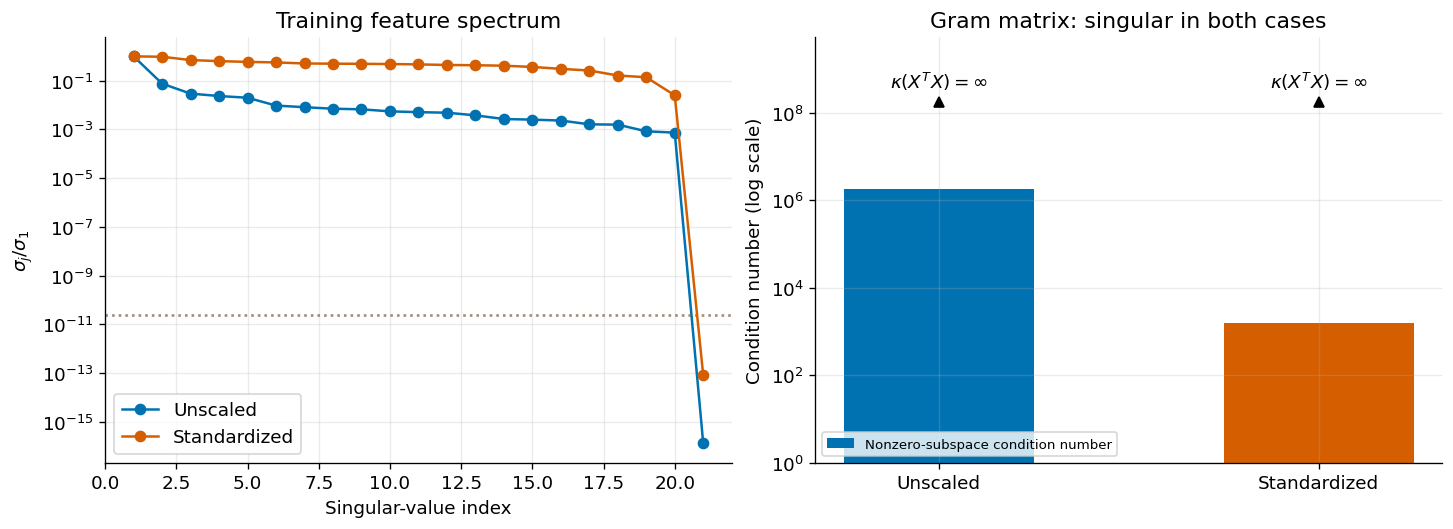

In [15]:
feature_rows, spectrum_rows = [], []
fig, axes = plt.subplots(1, 2, figsize=(12, 4.3), layout='constrained')
with threadpool_limits(limits=1):
    for label, matrix, color in [('Unscaled', training_values.to_numpy(float), '#0072B2'),
                                  ('Standardized', A, '#D55E00')]:
        singular = np.linalg.svd(matrix, compute_uv=False)
        tolerance = max(matrix.shape) * np.finfo(float).eps * singular[0]
        keep = singular > tolerance
        rank = int(keep.sum())
        kappa_nonzero = float((singular[0] / singular[keep][-1])**2)
        kappa_gram = float((singular[0] / singular[-1])**2) if rank == matrix.shape[1] else np.inf
        feature_rows.append({'Representation': label, 'Features': matrix.shape[1],
                             'Numerical rank': rank, 'SVD tolerance': tolerance,
                             'kappa(X.T X)': kappa_gram,
                             'Nonzero-subspace kappa(X.T X)': kappa_nonzero})
        for j, value in enumerate(singular, 1):
            spectrum_rows.append({'Representation': label, 'Index': j, 'Singular value': value,
                                 'Gram eigenvalue from SVD': value**2,
                                 'Numerically nonzero': bool(keep[j-1])})
        axes[0].semilogy(np.arange(1, len(singular)+1), singular/singular[0], 'o-',
                         color=color, label=label)
        axes[0].axhline(tolerance/singular[0], color=color, linestyle=':', alpha=.5)
feature_conditioning = pd.DataFrame(feature_rows).set_index('Representation')
save_table(feature_conditioning, 'feature_conditioning')
pd.DataFrame(spectrum_rows).to_csv(ARTIFACTS / 'feature_spectrum.csv', index=False)
assert (feature_conditioning['Numerical rank'] < A.shape[1]).all()
positions = np.arange(len(feature_conditioning))
finite_conditions = feature_conditioning['Nonzero-subspace kappa(X.T X)'].to_numpy()
axes[1].bar(positions, finite_conditions, width=.5, color=['#0072B2', '#D55E00'],
            label='Nonzero-subspace condition number')
cap = max(finite_conditions.max()*100, 1e4)
for pos, value in zip(positions, feature_conditioning['kappa(X.T X)']):
    if np.isinf(value):
        axes[1].plot(pos, cap, '^', color='black')
        axes[1].annotate(r'$\kappa(X^TX)=\infty$', (pos, cap), xytext=(0, 8),
                         textcoords='offset points', ha='center')
    else:
        axes[1].plot(pos, value, 'ko')
        
axes[0].set(xlabel='Singular-value index', ylabel=r'$\sigma_j / \sigma_1$',
            title='Training feature spectrum')
axes[0].legend()
axes[1].set(yscale='log', xticks=positions, xticklabels=feature_conditioning.index,
            ylabel='Condition number (log scale)', title='Gram matrix: singular in both cases',
            ylim=(1, cap*30))
axes[1].legend(loc='lower left', fontsize=8)
publish(fig, '03b_feature_conditioning')


## 3. Logistic regression: linear baseline
For $z=w^Tx+b$, minimize
$$J(w,b)=\frac1N\sum_i\log(1+e^{(1-2y_i)z_i})+\frac\lambda2\|w\|_2^2.$$
The intercept is unpenalized. `logaddexp` avoids overflow; SciPy L-BFGS-B uses
the analytic gradient. Six logarithmically spaced $\lambda$ values are compared
using validation AP, then validation log loss. Only the selected run is plotted.

At each fitted solution the Hessian is
$$H_\lambda=\widetilde X^T\operatorname{diag}(p_i(1-p_i))\widetilde X/N
 +\lambda\operatorname{diag}(1,\ldots,1,0).$$
Regularization lifts flat coefficient directions. A better curvature ratio can
help optimization, but L-BFGS iteration counts also depend on line search and
stopping criteria; no fixed convergence rate follows from this plot alone.


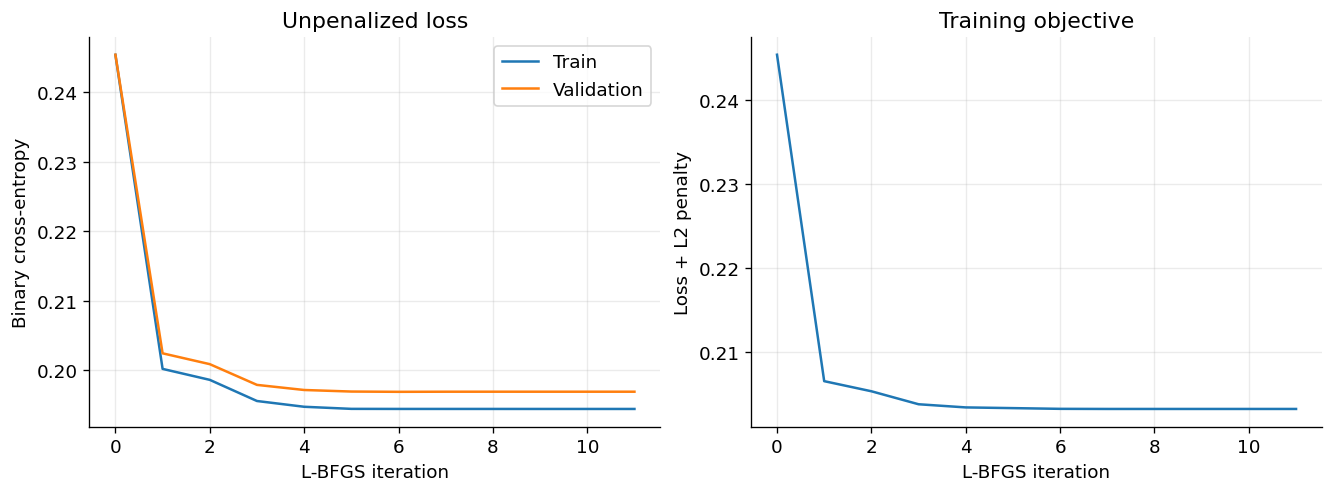

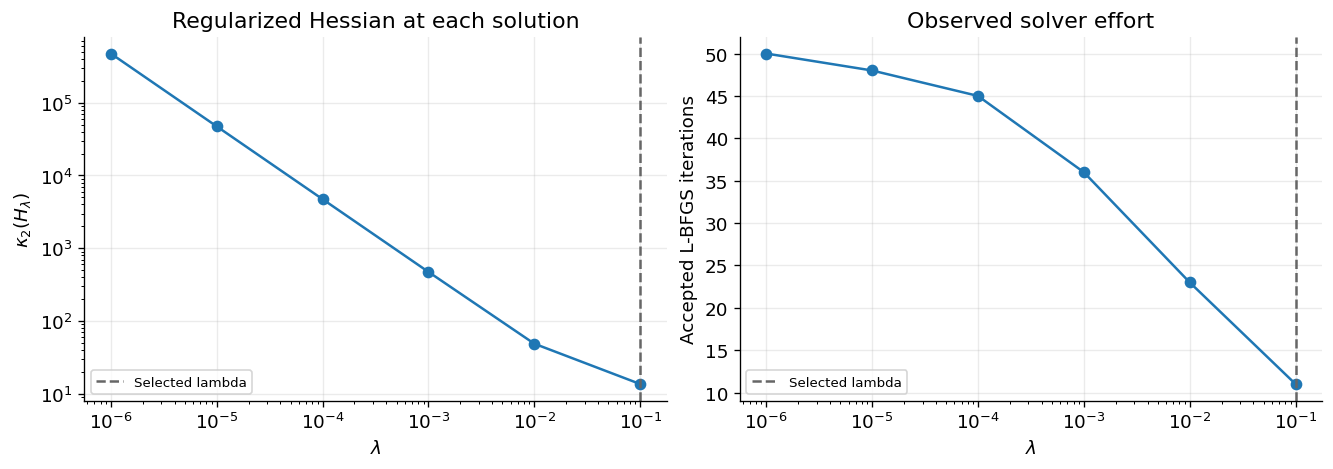

In [5]:
def linear_loss_gradient(theta, X, y, lam, kind):
    w, b = theta[:-1], theta[-1]
    z = X @ w + b
    if kind == 'logistic':
        losses = np.logaddexp(0, (1 - 2*y)*z)
        residual = expit(z) - y
    else:
        signed = 2*y - 1
        shortfall = np.maximum(0, 1 - signed*z)
        losses = shortfall**2
        residual = -2*signed*shortfall
    loss = losses.mean() + .5*lam*(w @ w)
    gradient = np.r_[X.T @ residual / len(y) + lam*w, residual.mean()]
    return loss, gradient


def fit_linear(X, V, y, vy, lam, kind='logistic', trace=False, run_id='linear'):
    start = perf_counter()
    initial = np.zeros(X.shape[1] + 1)
    initial[-1] = np.log(y.mean()/(1-y.mean())) if kind == 'logistic' else 2*y.mean()-1
    history, cache = [], {}
    def objective(theta):
        value, gradient = linear_loss_gradient(theta, X, y, lam, kind)
        cache.update(theta=theta.copy(), value=value, gradient=gradient.copy())
        return value, gradient
    def record(theta):
        if 'theta' not in cache or not np.array_equal(theta, cache['theta']):
            objective(theta)
        row = {'Iteration': len(history), 'Train objective': float(cache['value']),
               'Gradient infinity norm': float(np.max(np.abs(cache['gradient'])))}
        if trace:
            row['Train loss'] = cache['value'] - .5*lam*(theta[:-1] @ theta[:-1])
            row['Validation loss'] = linear_loss_gradient(theta, V, vy, 0, kind)[0]
        history.append(row)
    record(initial)
    with threadpool_limits(limits=1):
        result = minimize(objective, initial, jac=True, method='L-BFGS-B', callback=record,
                          options={'maxiter': 1500, 'ftol': 1e-11, 'gtol': 1e-6, 'maxls': 40})
    elapsed = perf_counter()-start
    history = pd.DataFrame(history)
    history.to_csv(LOGS / f'{run_id}.csv', index=False)
    finite = np.isfinite(result.fun) and np.isfinite(result.x).all() and np.isfinite(result.jac).all()
    success = bool(result.success and finite)
    stats = {'Run': run_id, 'Method': kind, 'Success': success, 'Status': int(result.status),
             'Termination': str(result.message), 'Iterations': int(result.nit),
             'Function evaluations': int(result.nfev), 'Gradient evaluations': int(result.njev),
             'Final objective': float(result.fun),
             'Gradient infinity norm': float(np.max(np.abs(result.jac))), 'Seconds': elapsed}
    SOLVER_RECORDS.append(stats)
    return {'theta': result.x, 'history': history, 'lambda': lam, 'seconds': elapsed,
            'iterations': result.nit, 'gradient_inf': stats['Gradient infinity norm'],
            'success': success, 'termination': str(result.message), 'run_id': run_id}

def linear_score(model, features):
    return features @ model['theta'][:-1] + model['theta'][-1]

def probability_metrics(labels, probabilities):
    p = np.asarray(probabilities)
    assert np.isfinite(p).all() and ((p >= 0) & (p <= 1)).all()
    return {'AP': average_precision_score(labels, p), 'ROC-AUC': roc_auc_score(labels, p),
            'Log loss': log_loss(labels, p), 'Brier': brier_score_loss(labels, p)}

def plot_linear_history(model, label, filename):
    h = model['history']
    fig, axes = plt.subplots(1, 2, figsize=(11, 4), layout='constrained')
    axes[0].plot(h.Iteration, h['Train loss'], label='Train')
    axes[0].plot(h.Iteration, h['Validation loss'], label='Validation')
    axes[0].set(xlabel='L-BFGS iteration', ylabel=label, title='Unpenalized loss')
    axes[0].legend()
    axes[1].plot(h.Iteration, h['Train objective'])
    axes[1].set(xlabel='L-BFGS iteration', ylabel='Loss + L2 penalty', title='Training objective')
    publish(fig, filename)


def search_logistic(train, valid, labels, valid_labels, seed, curvature=False):
    started, rows, curvature_rows = perf_counter(), [], []
    augmented = np.column_stack([train, np.ones(len(train))]) if curvature else None
    for lam in LR_GRID:
        fitted = fit_linear(train, valid, labels, valid_labels, lam,
                            run_id=f'seed_{seed}_lr_lambda_{lam:g}')
        row = {'lambda': lam, 'Success': fitted['success'], 'Iterations': fitted['iterations']}
        if fitted['success']:
            p = expit(linear_score(fitted, valid))
            row.update(probability_metrics(valid_labels, p))
            if curvature:
                pt = expit(linear_score(fitted, train))
                with threadpool_limits(limits=1):
                    H = augmented.T @ ((pt*(1-pt))[:, None]*augmented)/len(train)
                    H += np.diag(np.r_[np.full(train.shape[1], lam), 0.])
                    eigen = np.linalg.eigvalsh(H)
                curvature_rows.append({'lambda': lam, 'Hessian min eigenvalue': eigen[0],
                                       'Hessian max eigenvalue': eigen[-1],
                                       'Hessian condition': eigen[-1]/eigen[0],
                                       'Iterations': fitted['iterations'],
                                       'Gradient infinity norm': fitted['gradient_inf']})
        rows.append(row)
    table = pd.DataFrame(rows)
    table.to_csv(ARTIFACTS / f'logistic_search_seed_{seed}.csv', index=False)
    flush_solver_stats()
    eligible = table.loc[table.Success].sort_values(['AP', 'Log loss', 'lambda'],
                                                   ascending=[False, True, False])
    if eligible.empty:
        raise RuntimeError('No converged logistic candidate; inspect solver_termination_stats.csv.')
    selected = fit_linear(train, valid, labels, valid_labels, float(eligible.iloc[0]['lambda']),
                           trace=True, run_id=f'seed_{seed}_lr_selected')
    assert selected['success'], selected['termination']
    flush_solver_stats()
    return selected, table, pd.DataFrame(curvature_rows), perf_counter()-started

lr, lr_search, lr_curvature, lr_total_seconds = search_logistic(A, B, ya, yv, SEED, curvature=True)
lr_val = expit(linear_score(lr, B))
plot_linear_history(lr, 'Binary cross-entropy', '04_logistic_training')
save_table(lr_curvature, 'logistic_hessian_conditioning')
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8), layout='constrained')
axes[0].loglog(lr_curvature['lambda'], lr_curvature['Hessian condition'], 'o-')
axes[0].set(xlabel=r'$\lambda$', ylabel=r'$\kappa_2(H_\lambda)$', title='Regularized Hessian at each solution')
axes[1].semilogx(lr_curvature['lambda'], lr_curvature['Iterations'], 'o-')
axes[1].set(xlabel=r'$\lambda$', ylabel='Accepted L-BFGS iterations', title='Observed solver effort')
for ax in axes:
    ax.axvline(lr['lambda'], color='.4', linestyle='--', label='Selected lambda')
    ax.legend(fontsize=8)
publish(fig, '04b_logistic_curvature')


## 4. Nyström kernel SVM
### Margins, kernels and regularization
Write labels as $t_i=2y_i-1$. A linear SVM seeks a large margin by penalizing $\|w\|^2$
while charging observations with $t_if(x_i)<1$. Standard hinge loss is
$\max(0,1-t_if(x_i))$. Here we use **squared hinge loss**:
$$J(w,b)=\frac1N\sum_i\max(0,1-t_i(w^T\phi(x_i)+b))^2+\frac\lambda2\|w\|^2.$$
It is continuously differentiable, permits L-BFGS with an analytic gradient, and
penalizes large margin violations more strongly. Points with margin at least one
contribute zero loss gradient. This is an L2-regularized squared-hinge SVM, not logistic regression.
Larger $\lambda$ shrinks coefficients more; in the convention
$\frac12\|w\|^2+C\sum_i\ell_i$, $C=1/(N\lambda)$.

The RBF kernel $k(x,z)=\exp(-\gamma\|x-z\|^2)$ represents nonlinear similarity.
Small $\gamma$ gives broad similarities; large $\gamma$ gives local similarities.
A full $N\times N$ kernel matrix requires quadratic storage. Nyström uses $m\ll N$
training landmarks $L$, with $W=K(L,L)=Q\Lambda Q^T$ and $C_X=K(X,L)$:
$$\Phi_\epsilon(X)=C_XQ(\Lambda+\epsilon I)^{-1/2},\qquad
\widetilde K=\Phi_\epsilon\Phi_\epsilon^T=C_X(W+\epsilon I)^{-1}C_X^T.$$
No explicit inverse is formed. Fitting a linear SVM to $\Phi_\epsilon$ approximates
an RBF kernel classifier. The diagonal shift $\epsilon$ stabilizes small eigenvalues;
the classifier penalty $\lambda$ controls coefficient size. They have different roles.

The original spectral safeguard is retained: roundoff-scale negative eigenvalues
are shifted, materially negative ones raise an error, and the shifted condition
number is bounded by $10^8$. The shift introduces approximation bias.
Factorization costs $O(m^3)$; dense feature projection costs $O(Nm^2)$ plus
$O(Nmd)$ kernel evaluation, and features need $O(Nm)$ memory.

In [6]:
@jax.jit
def rbf_matrix(X, landmarks, gamma):
    # vmap batches row kernels; dot products avoid an N x M x D temporary.
    landmark_norms = jnp.sum(landmarks * landmarks, axis=1)
    def row_kernel(x):
        distances = jnp.maximum(jnp.sum(x*x) + landmark_norms - 2 * (landmarks @ x), 0.0)
        return jnp.exp(-gamma * distances)
    return jax.vmap(row_kernel)(X)


@jax.jit
def nystrom_projection(X, landmarks, gamma, factor):
    return rbf_matrix(X, landmarks, gamma) @ factor


@jax.jit
def kernel_spectrum(W):
    eigenvalues, eigenvectors = jnp.linalg.eigh(W)
    return eigenvalues, eigenvectors, jnp.linalg.svd(W, compute_uv=False)


class StableNystrom(BaseEstimator, TransformerMixin):
    def __init__(self, n_components=256, gamma=None, random_state=42,
                 condition_target=1e8, minimum_jitter=1e-6):
        self.n_components = n_components
        self.gamma = gamma
        self.random_state = random_state
        self.condition_target = condition_target
        self.minimum_jitter = minimum_jitter

    def fit(self, X_train_fold, y=None):
        X_train_fold = np.asarray(X_train_fold, dtype=float)
        if not 1 <= self.n_components <= len(X_train_fold):
            raise ValueError('Landmark count must not exceed training size.')
        rng = np.random.default_rng(self.random_state)
        if self.gamma is None:
            left, right = rng.integers(0, len(X_train_fold), size=(2, 10_000))
            d2 = np.sum((X_train_fold[left] - X_train_fold[right]) ** 2, axis=1)
            if not np.any(d2 > 0):
                raise ValueError('RBF bandwidth is undefined for identical training rows.')
            self.gamma_ = 1 / (16 * np.median(d2[d2 > 0]))
        else:
            self.gamma_ = float(self.gamma)
        # Separate generator makes landmark prefixes identical across m and fixed gamma.
        order = np.random.default_rng(self.random_state).permutation(len(X_train_fold))
        self.landmark_indices_ = order[:self.n_components]
        self.landmarks_ = X_train_fold[self.landmark_indices_].copy()
        W = np.asarray(rbf_matrix(jnp.asarray(self.landmarks_), jnp.asarray(self.landmarks_), self.gamma_))
        self.W_ = (W + W.T) / 2
        self.eigenvalues_, self.eigenvectors_, self.singular_values_ = (
            np.asarray(a) for a in kernel_spectrum(jnp.asarray(self.W_)))
        lo, hi = self.eigenvalues_[[0, -1]]
        self.tolerance_ = self.n_components * np.finfo(float).eps * hi
        if lo < -10 * self.tolerance_:
            raise FloatingPointError('Gram matrix has a materially negative eigenvalue.')
        self.raw_condition_ = (self.singular_values_[0] / self.singular_values_[-1]
                               if self.singular_values_[-1] > 0 else np.inf)
        unsafe = lo <= self.tolerance_ or self.raw_condition_ > self.condition_target
        self.jitter_ = max(self.minimum_jitter,
            (hi - self.condition_target * lo) / (self.condition_target - 1),
            self.tolerance_ - lo) if unsafe else 0.0
        shifted = self.eigenvalues_ + self.jitter_
        assert np.all(shifted > 0)
        self.regularized_condition_ = float(shifted[-1] / shifted[0])
        assert self.regularized_condition_ <= self.condition_target * (1 + 1e-6)
        self.factor_ = jnp.asarray(self.eigenvectors_) / jnp.sqrt(jnp.asarray(shifted))[None, :]
        self.device_landmarks_ = jnp.asarray(self.landmarks_)
        return self

    def transform(self, X):
        Phi = np.asarray(nystrom_projection(jnp.asarray(X), self.device_landmarks_, self.gamma_, self.factor_))
        assert np.isfinite(Phi).all()
        return Phi

    def pseudoinverse_features(self, X):
        keep = self.eigenvalues_ > self.tolerance_
        factor = self.eigenvectors_[:, keep] / np.sqrt(self.eigenvalues_[keep])[None, :]
        return np.asarray(nystrom_projection(jnp.asarray(X), self.device_landmarks_, self.gamma_, jnp.asarray(factor)))

### Bounded selection and probability mapping
Jointly search $m\in\{64,128,256,512\}$,
$\gamma=s/\mathrm{median}(\|x_i-x_j\|^2)$ with $s\in\{1/16,1/4,1\}$,
and $\lambda\in\{10^{-5},10^{-4},10^{-3},10^{-2}\}$: **48 candidates**.
Distances and landmarks use training rows only. Nested landmark sets and a
shared distance sample control randomness within each split. Select by validation
AP, then validation squared-hinge loss; smaller maps break remaining ties.

After selection, fit $p=\sigma(af+b)$, $a\ge0$, on validation only. This preserves
score ranking unless the slope is zero. Reusing validation for calibration and
thresholds can make validation results optimistic; test labels enter neither fit.
The following landmark sweep holds the selected bandwidth and penalty fixed:
it is a numerical diagnostic and does not override the joint search.


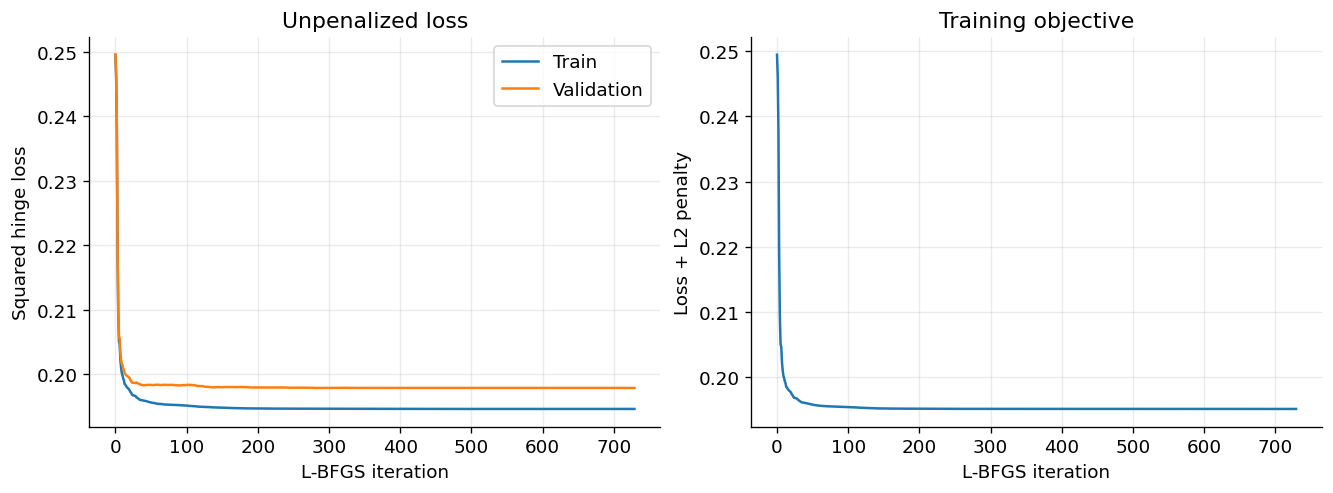

In [7]:
def search_nystrom(train, valid, labels, valid_labels, seed):
    started = perf_counter()
    rng = np.random.default_rng(seed)
    pair_ids = rng.integers(0, len(train), size=(2, 10_000))
    d2 = np.sum((train[pair_ids[0]]-train[pair_ids[1]])**2, axis=1)
    median_d2 = float(np.median(d2[d2 > 0]))
    rows, best_key, best = [], None, None
    with threadpool_limits(limits=1):
        for m in NYSTROM_M_GRID:
            for scale in NYSTROM_SCALE_GRID:
                mapping = StableNystrom(m, gamma=scale/median_d2, random_state=seed).fit(train)
                Z, V = mapping.transform(train), mapping.transform(valid)
                for lam in SVM_L2_GRID:
                    fitted = fit_linear(Z, V, labels, valid_labels, lam, 'svm',
                                        run_id=f'seed_{seed}_svm_m_{m}_s_{scale:g}_lambda_{lam:g}')
                    row = {'Landmarks': m, 'Bandwidth scale': scale, 'gamma': scale/median_d2,
                           'lambda': lam, 'Success': fitted['success'],
                           'Raw condition': mapping.raw_condition_,
                           'Shifted condition': mapping.regularized_condition_,
                           'Spectral shift': mapping.jitter_, 'Iterations': fitted['iterations']}
                    if fitted['success']:
                        score = linear_score(fitted, V)
                        ap = average_precision_score(valid_labels, score)
                        hinge = linear_loss_gradient(fitted['theta'], V, valid_labels, 0, 'svm')[0]
                        row.update({'Validation AP': ap, 'Validation squared hinge': hinge})
                        key = (-ap, hinge, m, -lam, scale)
                        if best_key is None or key < best_key:
                            best_key, best = key, (mapping, fitted, scale)
                    rows.append(row)
                del Z, V
    table = pd.DataFrame(rows)
    table.to_csv(ARTIFACTS / f'nystrom_search_seed_{seed}.csv', index=False)
    flush_solver_stats()
    if best is None:
        raise RuntimeError('No converged SVM candidate; inspect solver_termination_stats.csv.')
    mapping, fitted, scale = best
    Z, V = mapping.transform(train), mapping.transform(valid)
    fitted = fit_linear(Z, V, labels, valid_labels, fitted['lambda'], 'svm', trace=True,
                        run_id=f'seed_{seed}_svm_selected')
    assert fitted['success'], fitted['termination']
    flush_solver_stats()
    return mapping, fitted, scale, table, perf_counter()-started

def fit_sigmoid(scores, labels, seed):
    mean, std = float(np.mean(scores)), float(np.std(scores))
    assert std > 0
    design = ((scores-mean)/std)[:, None]
    history = []
    def record(theta):
        value, gradient = linear_loss_gradient(theta, design, labels, 1e-6, 'logistic')
        history.append({'Iteration': len(history), 'Objective': value,
                        'Gradient infinity norm': float(np.max(np.abs(gradient)))})
    initial = np.array([1., np.log(labels.mean()/(1-labels.mean()))])
    record(initial)
    start = perf_counter()
    result = minimize(linear_loss_gradient, initial, args=(design, labels, 1e-6, 'logistic'),
                      jac=True, method='L-BFGS-B', bounds=[(0, None), (None, None)],
                      callback=record, options={'ftol': 1e-12, 'gtol': 1e-8, 'maxiter': 1000})
    gradient = result.jac.copy()
    if result.x[0] <= 1e-12 and gradient[0] > 0:
        gradient[0] = 0.  # Projected gradient for the nonnegative slope constraint.
    SOLVER_RECORDS.append({'Run': f'seed_{seed}_svm_calibration', 'Method': 'sigmoid calibration',
                          'Success': bool(result.success), 'Status': int(result.status),
                          'Termination': str(result.message), 'Iterations': int(result.nit),
                          'Function evaluations': int(result.nfev),
                          'Gradient evaluations': int(result.njev), 'Final objective': float(result.fun),
                          'Gradient infinity norm': float(np.max(np.abs(result.jac))),
                          'Projected gradient infinity norm': float(np.max(np.abs(gradient))),
                          'Seconds': perf_counter()-start})
    pd.DataFrame(history).to_csv(LOGS / f'seed_{seed}_svm_calibration.csv', index=False)
    flush_solver_stats()
    assert result.success and np.isfinite(result.x).all(), result.message
    return {'theta': result.x, 'mean': mean, 'std': std}

def calibrated_svm_probability(scores, calibration):
    a, b = calibration['theta']
    return expit(a*(scores-calibration['mean'])/calibration['std'] + b)

nys, svm, bandwidth_scale, nys_search, nys_total_seconds = search_nystrom(A, B, ya, yv, SEED)
gamma, svm_lam = nys.gamma_, svm['lambda']
svm_train_score = linear_score(svm, nys.transform(A))
svm_val_score = linear_score(svm, nys.transform(B))
sigmoid_params = fit_sigmoid(svm_val_score, yv, SEED)
def svm_probability(scores):
    return calibrated_svm_probability(scores, sigmoid_params)
nys_val = svm_probability(svm_val_score)
plot_linear_history(svm, 'Squared hinge loss', '05_svm_training')


### Landmark spectrum, approximation and diagonal jitter
At the selected bandwidth, compare nested landmark matrices $W$ across $m$.
Eigenvalues near the roundoff tolerance indicate numerical rank deficiency.
The positive-definite shift gives
$$\kappa_2(W+\varepsilon I)=
\frac{\lambda_{\max}(W)+\varepsilon}{\lambda_{\min}(W)+\varepsilon}.$$
Only numerically positive-definite shifts are plotted; the selected safeguard
targets $\kappa\le10^8$. Eigensolvers can decompose a singular matrix, but forming
inverse-square-root features from tiny eigenvalues amplifies errors. No explicit
matrix inverse is formed. Jitter stabilizes this operation and changes the kernel.

The fixed-bandwidth approximation plot uses the same 1,200 validation rows for
all $m$. Lower Frobenius reconstruction error need not improve classification.


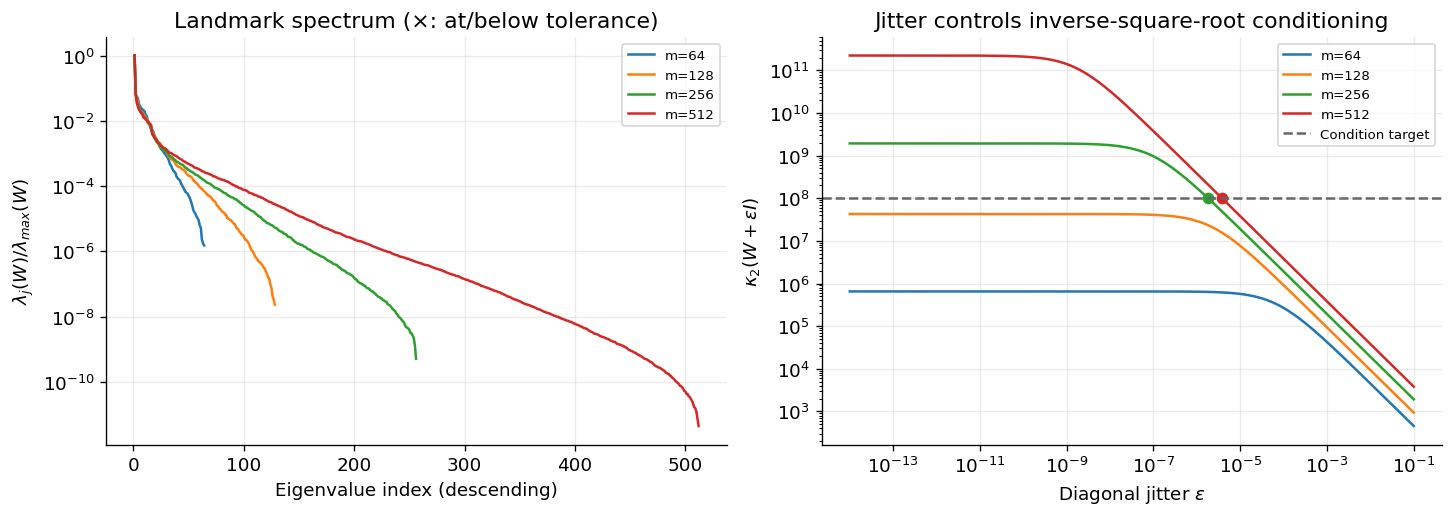

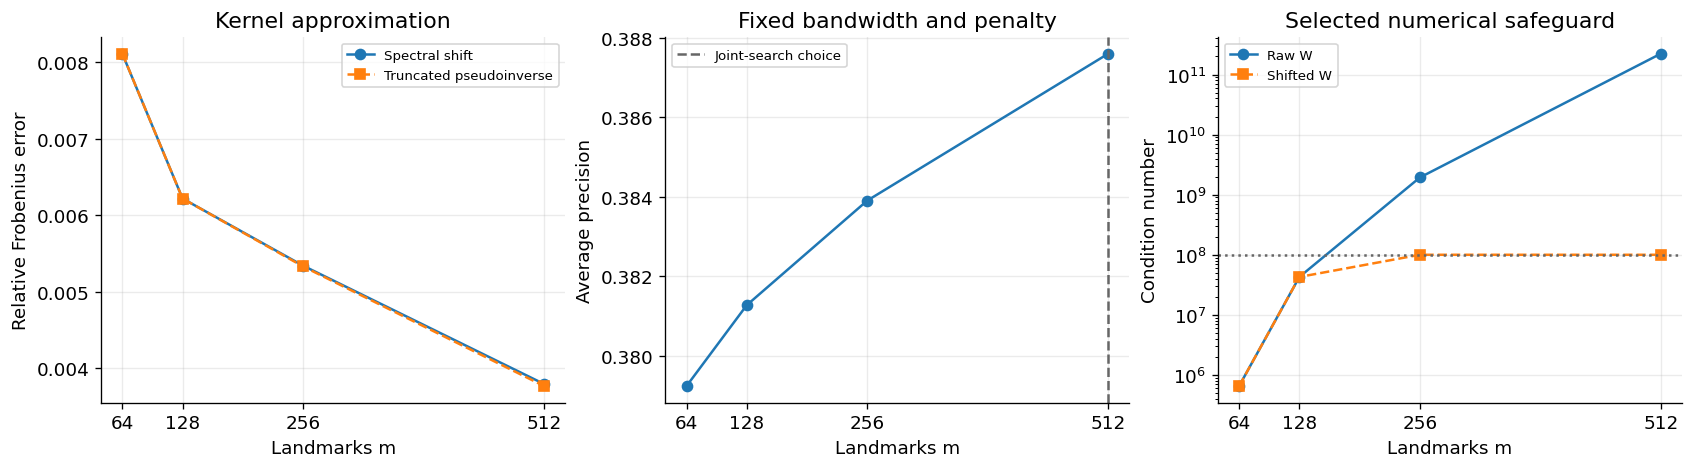

In [8]:
diagnostic_ids = np.random.default_rng(SEED).choice(len(B), 1200, replace=False)
E = B[diagnostic_ids]
K = rbf_kernel(E, gamma=gamma)
normK = np.linalg.norm(K, 'fro')
rank_rows, eigen_rows, jitter_rows = [], [], []
fig_spectral, spectral_axes = plt.subplots(1, 2, figsize=(12, 4.2), layout='constrained')
with threadpool_limits(limits=1):
    for m in NYSTROM_M_GRID:
        started = perf_counter()
        mapping = nys if m == nys.n_components else StableNystrom(m, gamma=gamma, random_state=SEED).fit(A)
        Z, V = mapping.transform(A), mapping.transform(B)
        fitted = svm if m == nys.n_components else fit_linear(
            Z, V, ya, yv, svm_lam, 'svm', run_id=f'seed_{SEED}_landmark_diagnostic_m_{m}')
        ap = average_precision_score(yv, linear_score(fitted, V)) if fitted['success'] else np.nan
        Phi, P0 = mapping.transform(E), mapping.pseudoinverse_features(E)
        rank_rows.append({'Landmarks': m, 'Validation AP': ap,
                         'Relative kernel error': np.linalg.norm(K-Phi@Phi.T, 'fro')/normK,
                         'Pseudoinverse error': np.linalg.norm(K-P0@P0.T, 'fro')/normK,
                         'Raw condition': mapping.raw_condition_,
                         'Shifted condition': mapping.regularized_condition_,
                         'Spectral shift': mapping.jitter_, 'Success': fitted['success'],
                         'Seconds': perf_counter()-started})
        eigen = mapping.eigenvalues_[::-1]
        hi, lo = float(eigen[0]), float(eigen[-1])
        ratio = eigen/hi
        reliable = eigen > mapping.tolerance_
        line, = spectral_axes[0].semilogy(np.arange(1, m+1)[reliable], ratio[reliable], label=f'm={m}')
        spectral_axes[0].semilogy(np.arange(1, m+1)[~reliable],
                                  np.full((~reliable).sum(), mapping.tolerance_/hi), 'x',
                                  color=line.get_color(), markersize=4)
        for j, value in enumerate(eigen, 1):
            eigen_rows.append({'Landmarks': m, 'Eigenvalue index': j, 'Eigenvalue': value,
                               'Relative eigenvalue': value/hi, 'Tolerance': mapping.tolerance_,
                               'Above tolerance': bool(value > mapping.tolerance_)})
        epsilons = np.unique(np.r_[np.logspace(-14, -1, 180), mapping.jitter_])
        positive = lo + epsilons > mapping.tolerance_
        conditions = np.full(len(epsilons), np.nan)
        conditions[positive] = (hi+epsilons[positive])/(lo+epsilons[positive])
        plot_mask = positive & (epsilons > 0)
        spectral_axes[1].loglog(epsilons[plot_mask], conditions[plot_mask],
                                color=line.get_color(), label=f'm={m}')
        if mapping.jitter_ > 0:
            spectral_axes[1].plot(mapping.jitter_, mapping.regularized_condition_, 'o',
                                  color=line.get_color())
        for eps, cond, valid in zip(epsilons, conditions, positive):
            jitter_rows.append({'Landmarks': m, 'Jitter': eps, 'Shifted condition': cond,
                                'Numerically positive definite': bool(valid),
                                'Selected jitter': bool(eps == mapping.jitter_)})
        del Z, V
rank_results = pd.DataFrame(rank_rows).set_index('Landmarks')
save_table(rank_results, 'landmark_study')
pd.DataFrame(eigen_rows).to_csv(ARTIFACTS / 'nystrom_eigenvalue_spectra.csv', index=False)
pd.DataFrame(jitter_rows).to_csv(ARTIFACTS / 'nystrom_jitter_sweep.csv', index=False)
flush_solver_stats()
spectral_axes[0].set(xlabel='Eigenvalue index (descending)', ylabel=r'$\lambda_j(W)/\lambda_{max}(W)$',
                     title='Landmark spectrum (×: at/below tolerance)')
spectral_axes[1].axhline(1e8, color='.4', linestyle='--', label='Condition target')
spectral_axes[1].set(xlabel=r'Diagonal jitter $\varepsilon$', ylabel=r'$\kappa_2(W+\varepsilon I)$',
                     title='Jitter controls inverse-square-root conditioning')
for ax in spectral_axes:
    ax.legend(fontsize=8)
publish(fig_spectral, '06a_nystrom_spectrum_jitter')

fig, axes = plt.subplots(1, 3, figsize=(14, 3.8), layout='constrained')
axes[0].plot(rank_results.index, rank_results['Relative kernel error'], 'o-', label='Spectral shift')
axes[0].plot(rank_results.index, rank_results['Pseudoinverse error'], 's--', label='Truncated pseudoinverse')
axes[0].set(xlabel='Landmarks m', ylabel='Relative Frobenius error', title='Kernel approximation')
axes[0].legend(fontsize=8)
axes[1].plot(rank_results.index, rank_results['Validation AP'], 'o-')
axes[1].axvline(nys.n_components, color='.4', linestyle='--', label='Joint-search choice')
axes[1].set(xlabel='Landmarks m', ylabel='Average precision', title='Fixed bandwidth and penalty')
axes[1].legend(fontsize=8)
axes[2].semilogy(rank_results.index, rank_results['Raw condition'], 'o-', label='Raw W')
axes[2].semilogy(rank_results.index, rank_results['Shifted condition'], 's--', label='Shifted W')
axes[2].axhline(1e8, color='.4', linestyle=':')
axes[2].set(xlabel='Landmarks m', ylabel='Condition number', title='Selected numerical safeguard')
axes[2].legend(fontsize=8)
for ax in axes:
    ax.set_xticks(rank_results.index)
publish(fig, '06b_landmark_count')
del K, Phi, P0


## 5. JAX MLP: bounded optimization search
ReLU hidden layers, a linear output logit, Glorot initialization and Adam minimize
$$\mathcal L(\theta)=\frac1N\sum_i\operatorname{logaddexp}(0,(1-2y_i)z_\theta(x_i))
 +\frac\lambda2\sum_\ell\|W_\ell\|_F^2.$$
Biases are unpenalized; L2 enters Adam's gradient. Float64 and loss-from-logits
avoid avoidable rounding/overflow; they do not guarantee convergence.

Compare `(54,)` and `(32,16)` (approximately equal parameter counts), three
learning rates and three L2 strengths: **18 candidates**. Batch size 256, maximum
60 epochs and patience 8 stay fixed. Early stopping restores the lowest validation
BCE checkpoint; validation AP selects the configuration, with BCE breaking ties.
This compares tuned predictors, not an isolated causal effect of depth.
Only the selected run's loss and relative-update curves are displayed.


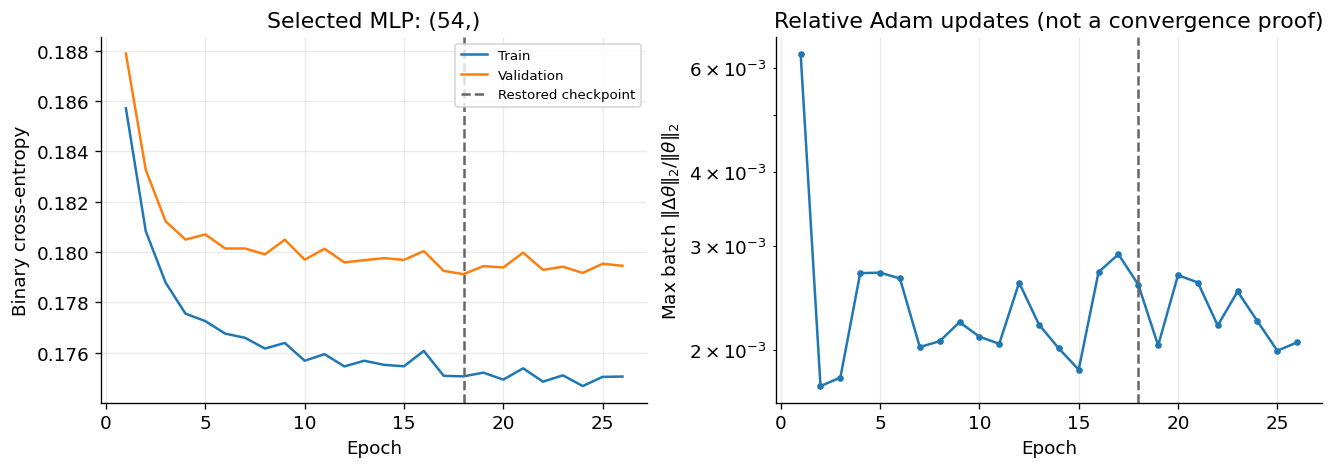

In [9]:
@jax.jit
def stable_sigmoid(z):
    return jax.nn.sigmoid(jnp.asarray(z, dtype=jnp.float64))


@jax.jit
def bce_from_logits(z, y):
    return jnp.logaddexp(0.0, (1 - 2 * jnp.asarray(y, dtype=jnp.float64)) * jnp.asarray(z))


@jax.jit
def mlp_forward(params, X):
    activations = [X]
    for W, b in zip(params[:-2:2], params[1:-2:2]):
        activations.append(jax.nn.relu(activations[-1] @ W + b))
    return (activations[-1] @ params[-2] + params[-1]).ravel(), activations


@jax.jit
def mlp_objective(params, X, y, sample_weight, lam, mask):
    logits, _ = mlp_forward(params, X)
    data = jnp.sum(mask * sample_weight * bce_from_logits(logits, y)) / jnp.sum(mask)
    penalty = lam / 2 * sum(jnp.sum(W * W) for W in params[::2])
    return data + penalty


mlp_value_and_grad = jax.jit(jax.value_and_grad(mlp_objective))


@jax.jit
def mlp_epoch(params, m, v, step, X, y, sample_weight, batch_indices, masks, lam, rate):
    """Compile all Adam minibatches together; padding has zero contribution."""
    def update(state, batch):
        params, m, v, step = state
        indices, mask = batch
        loss, grads = mlp_value_and_grad(
            params, X[indices], y[indices], sample_weight[indices], lam, mask)
        step = step + 1
        m = [0.9 * old + 0.1 * g for old, g in zip(m, grads)]
        v = [0.999 * old + 0.001 * g**2 for old, g in zip(v, grads)]
        updates = [rate * (a / (1 - 0.9**step)) / (jnp.sqrt(b / (1 - 0.999**step)) + 1e-8)
                   for a, b in zip(m, v)]
        update2 = sum(jnp.sum(u*u) for u in updates)
        parameter2 = sum(jnp.sum(p*p) for p in params)
        finite = jnp.isfinite(loss) & jnp.all(jnp.stack([jnp.all(jnp.isfinite(g)) for g in grads]))
        params = [p - u for p, u in zip(params, updates)]
        finite &= jnp.all(jnp.stack([jnp.all(jnp.isfinite(p)) for p in params]))
        diagnostics = (update2, jnp.sqrt(update2) / jnp.maximum(jnp.sqrt(parameter2), 1e-15), finite)
        return (params, m, v, step), diagnostics

    state, (update2, relative, finite) = jax.lax.scan(
        update, (params, m, v, step), (batch_indices, masks))
    return state, (jnp.sqrt(jnp.mean(update2)), jnp.max(relative), jnp.all(finite))


def padded_batches(indices, batch_size):
    if batch_size < 1 or len(indices) == 0:
        raise ValueError('A positive batch size and nonempty data are required.')
    n = len(indices)
    padded_n = ((n + batch_size - 1) // batch_size) * batch_size
    # Index zero is safe to gather; the mask removes padded observations.
    padded = jnp.pad(indices, (0, padded_n - n))
    mask = (jnp.arange(padded_n) < n).astype(jnp.float64)
    return padded.reshape(-1, batch_size), mask.reshape(-1, batch_size)


class CreditMLP:
    def __init__(self, input_dim, hidden=(32, 16), seed=42, lam=1e-5, learning_rate=1e-3):
        self.key = jax.random.key(seed)
        sizes = (input_dim, *hidden, 1)
        self.params = []
        for a, b in zip(sizes[:-1], sizes[1:]):
            self.key, subkey = jax.random.split(self.key)
            bound = jnp.sqrt(6.0 / (a + b))
            self.params.extend([jax.random.uniform(subkey, (a, b), dtype=jnp.float64,
                                                   minval=-bound, maxval=bound),
                                jnp.zeros((1, b), dtype=jnp.float64)])
        self.m = [jnp.zeros_like(p) for p in self.params]
        self.v = [jnp.zeros_like(p) for p in self.params]
        self.step = jnp.asarray(0, dtype=jnp.int64)
        self.lam, self.learning_rate = lam, learning_rate

    @property
    def weights(self):
        return self.params[::2]

    @property
    def biases(self):
        return self.params[1::2]

    def forward(self, X):
        return mlp_forward(self.params, jnp.asarray(X, dtype=jnp.float64))

    def predict_logits(self, X):
        return self.forward(X)[0]

    def predict_probability(self, X):
        # Public classifier boundary: pandas/scikit-learn consume host arrays.
        return np.asarray(stable_sigmoid(self.predict_logits(X)))

    def objective(self, X, y, sample_weight):
        return float(mlp_objective(self.params, jnp.asarray(X), jnp.asarray(y),
                                  jnp.asarray(sample_weight), self.lam, jnp.ones(len(y))))

    def gradients(self, X, y, sample_weight):
        return mlp_value_and_grad(self.params, jnp.asarray(X), jnp.asarray(y),
                                  jnp.asarray(sample_weight), self.lam, jnp.ones(len(y)))[1]

    def epoch(self, X, y, sample_weight, batch_size=256):
        self.key, subkey = jax.random.split(self.key)
        indices, masks = padded_batches(jax.random.permutation(subkey, len(y)), batch_size)
        state, diagnostics = mlp_epoch(self.params, self.m, self.v, self.step,
            jnp.asarray(X), jnp.asarray(y), jnp.asarray(sample_weight), indices, masks,
            self.lam, self.learning_rate)
        self.params, self.m, self.v, self.step = state
        rms, relative, finite = jax.device_get(diagnostics)
        if not finite:
            raise FloatingPointError('Non-finite loss, gradient or parameter.')
        return {'Adam step RMS': float(rms), 'Adam relative step max': float(relative)}



def train_mlp(hidden, train, valid, labels, valid_labels, seed, lam, learning_rate, run_id):
    start = perf_counter()
    model = CreditMLP(train.shape[1], hidden=hidden, seed=seed, lam=lam, learning_rate=learning_rate)
    train_device, val_device = jnp.asarray(train), jnp.asarray(valid)
    device_labels, device_valid_labels = jnp.asarray(labels), jnp.asarray(valid_labels)
    weights = jnp.ones(len(labels))
    best_loss, stale, history = np.inf, 0, []
    for epoch in range(1, MAX_EPOCHS + 1):
        diagnostics = model.epoch(train_device, device_labels, weights, batch_size=BATCH_SIZE)
        train_loss = float(bce_from_logits(model.predict_logits(train_device), device_labels).mean())
        valid_loss = float(bce_from_logits(model.predict_logits(val_device), device_valid_labels).mean())
        penalty = .5*lam*sum(float(jnp.sum(w*w)) for w in model.weights)
        if not np.isfinite([train_loss, valid_loss, penalty]).all():
            raise FloatingPointError('Non-finite MLP loss.')
        history.append({'Epoch': epoch, 'Train BCE': train_loss, 'Validation BCE': valid_loss,
                        'Train objective': train_loss+penalty, **diagnostics})
        if valid_loss < best_loss - 1e-5:
            best_loss, stale, model.best_epoch_ = valid_loss, 0, epoch
            best_params = list(model.params)
        else:
            stale += 1
        if stale >= PATIENCE:
            break
    model.params = best_params
    model.history_ = pd.DataFrame(history)
    model.seconds_ = perf_counter()-start
    model.history_.to_csv(LOGS / f'{run_id}.csv', index=False)
    SOLVER_RECORDS.append({'Run': run_id, 'Method': 'Adam', 'Success': True,
                          'Termination': 'Validation patience' if stale >= PATIENCE else 'Maximum epochs',
                          'Iterations': len(history), 'Best epoch': model.best_epoch_,
                          'Restored validation BCE': best_loss, 'Seconds': model.seconds_})
    return model

def parameter_count(d, hidden):
    sizes = (d, *hidden, 1)
    return sum((a+1)*b for a,b in zip(sizes[:-1], sizes[1:]))

deep = (32, 16)
shallow = (round((parameter_count(A.shape[1], deep)-1)/(A.shape[1]+2)),)
architectures = {'1 hidden layer': shallow, '2 hidden layers': deep}

def search_mlp(train, valid, labels, valid_labels, seed):
    started, rows, best_key, best = perf_counter(), [], None, None
    with threadpool_limits(limits=1):
        for name, hidden in architectures.items():
            for rate in MLP_RATE_GRID:
                for lam in MLP_L2_GRID:
                    run_id = f'seed_{seed}_mlp_{len(hidden)}layer_rate_{rate:g}_lambda_{lam:g}'
                    net = train_mlp(hidden, train, valid, labels, valid_labels, seed, lam, rate, run_id)
                    metrics = probability_metrics(valid_labels, net.predict_probability(valid))
                    row = {'Architecture': name, 'Hidden widths': str(hidden),
                           'Parameters': parameter_count(train.shape[1], hidden),
                           'Learning rate': rate, 'lambda': lam, 'Best epoch': net.best_epoch_,
                           'Epochs run': len(net.history_), **metrics,
                           'Seconds (including JIT)': net.seconds_, 'Run': run_id}
                    rows.append(row)
                    key = (-metrics['AP'], metrics['Log loss'], row['Parameters'], rate, -lam)
                    if best_key is None or key < best_key:
                        best_key, best = key, (name, net, row)
    table = pd.DataFrame(rows)
    table.to_csv(ARTIFACTS / f'mlp_search_seed_{seed}.csv', index=False)
    flush_solver_stats()
    name, model, selected_row = best
    return name, model, selected_row, table, perf_counter()-started

selected_architecture, mlp, mlp_selected, mlp_results, mlp_total_seconds = search_mlp(A, B, ya, yv, SEED)
mlp_val = mlp.predict_probability(B)
h = mlp.history_
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8), layout='constrained')
axes[0].plot(h.Epoch, h['Train BCE'], label='Train')
axes[0].plot(h.Epoch, h['Validation BCE'], label='Validation')
axes[0].axvline(mlp.best_epoch_, color='.4', linestyle='--', label='Restored checkpoint')
axes[0].set(xlabel='Epoch', ylabel='Binary cross-entropy', title=f'Selected MLP: {mlp_selected["Hidden widths"]}')
axes[0].legend(fontsize=8)
axes[1].semilogy(h.Epoch, h['Adam relative step max'], 'o-', markersize=3)
axes[1].axvline(mlp.best_epoch_, color='.4', linestyle='--')
axes[1].set(xlabel='Epoch', ylabel=r'Max batch $\|\Delta\theta\|_2/\|\theta\|_2$',
            title='Relative Adam updates (not a convergence proof)')
publish(fig, '07_selected_mlp_training')


### Brief comparison: automatic and numerical differentiation
`jax.value_and_grad` applies reverse-mode automatic differentiation (AD): chain-rule
derivatives of the implemented operations give all parameter gradients for a scalar
loss at a cost comparable to a small number of forward evaluations. AD has floating-point
roundoff, but no finite-difference step-size truncation error. JIT compilation is a
separate transformation.

Central finite differences use
$d_h=[\mathcal L(\theta+hv)-\mathcal L(\theta-hv)]/(2h)$ to approximate
$\nabla\mathcal L(\theta)^Tv$. On smooth regions the error combines $O(h^2)$
truncation and approximately $O(u/h)$ roundoff. A full coordinate gradient requires
two loss evaluations per parameter; a directional check needs only two per step size.
We use AD for training and finite differences only to check a small synthetic network.
ReLU is nonsmooth at zero, so steps changing activation patterns are marked separately.

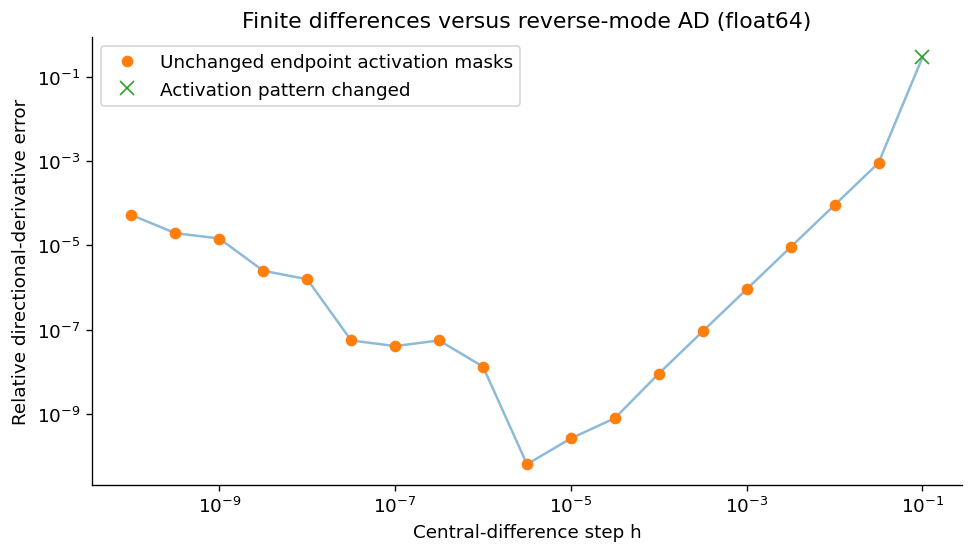

**Observed step-size behaviour.** The smallest measured relative error is 6.321e-11, at h=3.2e-06. Taking an even smaller step eventually loses accuracy through rounding; a larger step has truncation error and can also change the ReLU activation pattern. This minimum is specific to the synthetic network, direction and float64 evaluation.

Passed: extreme-logit loss, directional gradient check, singular-landmark factorization.


In [10]:
def finite_difference_step_study():
    rng = np.random.default_rng(170)
    A = rng.normal(size=(11, 3))
    y = rng.integers(0, 2, size=11).astype(float)
    weights = np.ones(len(y))
    net = CreditMLP(3, hidden=(4, 3), seed=17, lam=0.3)
    original = list(net.params)
    directions = [rng.normal(size=p.shape) for p in original]
    scale = np.sqrt(sum(np.sum(d*d) for d in directions))
    directions = [jnp.asarray(d/scale) for d in directions]
    gradients = net.gradients(A, y, weights)
    target = float(sum(jnp.sum(g*d) for g, d in zip(gradients, directions)))
    centre_masks = [np.asarray(a > 0) for a in net.forward(A)[1][1:]]
    rows = []
    try:
        for h in np.logspace(-1, -10, 19):
            values, unchanged = [], True
            for sign in (1, -1):
                net.params = [p + sign*h*d for p, d in zip(original, directions)]
                values.append(net.objective(A, y, weights))
                endpoint_masks = [np.asarray(a > 0) for a in net.forward(A)[1][1:]]
                unchanged &= all(np.array_equal(a, b) for a, b in zip(centre_masks, endpoint_masks))
            difference = (values[0] - values[1]) / (2*h)
            rows.append({'h': h, 'Central difference': difference, 'AD derivative': target,
                         'Absolute error': abs(difference-target),
                         'Relative error': abs(difference-target)/max(abs(target), 1e-15),
                         'Endpoint activation masks unchanged': unchanged})
    finally:
        net.params = original
    table = pd.DataFrame(rows)
    safe = table['Endpoint activation masks unchanged']
    assert safe.sum() >= 3 and table.loc[safe, 'Relative error'].min() < 1e-7
    fig, ax = plt.subplots(figsize=(8, 4.5), layout='constrained')
    ax.loglog(table['h'], np.maximum(table['Relative error'], 1e-18), '-', alpha=.5)
    ax.loglog(table.loc[safe, 'h'], np.maximum(table.loc[safe, 'Relative error'], 1e-18),
              'o', label='Unchanged endpoint activation masks')
    if (~safe).any():
        ax.loglog(table.loc[~safe, 'h'], np.maximum(table.loc[~safe, 'Relative error'], 1e-18),
                  'x', markersize=8, label='Activation pattern changed')
    ax.set(xlabel='Central-difference step h', ylabel='Relative directional-derivative error',
           title='Finite differences versus reverse-mode AD (float64)')
    ax.grid(); ax.legend()
    publish(fig, '08_ad_step_size')
    table.to_csv(ARTIFACTS / 'ad_step_size.csv', index=False)
    return table

ad_step_diagnostics = finite_difference_step_study()
eligible = ad_step_diagnostics[ad_step_diagnostics['Endpoint activation masks unchanged']]
best = eligible.loc[eligible['Relative error'].idxmin()]
display(Markdown(
    f"**Observed step-size behaviour.** The smallest measured relative error is "
    f"{best['Relative error']:.3e}, at h={best['h']:.1e}. "
    "Taking an even smaller step eventually loses accuracy through rounding; "
    "a larger step has truncation error and can also change the ReLU activation pattern. "
    "This minimum is specific to the synthetic network, direction and float64 evaluation."
))
# Focused stability and kernel checks, independent of the credit labels.
extreme = np.array([-1e6, -1000., 0., 1000., 1e6])
assert np.isfinite(bce_from_logits(extreme, np.array([1, 0, 1, 0, 1]))).all()
duplicated = np.repeat(np.random.default_rng(SEED).normal(size=(4, 3)), 2, axis=0)
tiny = StableNystrom(8, gamma=.2).fit(duplicated)
query = np.random.default_rng(SEED+1).normal(size=(6, 3))
C = rbf_kernel(query, tiny.landmarks_, gamma=tiny.gamma_)
P = tiny.transform(query)
assert tiny.jitter_ > 0
assert np.allclose(P@P.T, C@np.linalg.solve(tiny.W_+tiny.jitter_*np.eye(8), C.T), atol=1e-8)
print('Passed: extreme-logit loss, directional gradient check, singular-landmark factorization.')


## 6. Final comparison: Logistic Regression, Nyström SVM and JAX MLP
The table reports the selected configurations for the representative split (seed 42).
Average precision (AP) is the step-weighted precision–recall summary, not trapezoidal
PR-AUC. ROC-AUC measures ranking; log loss and Brier measure probability quality.
The figures use frozen test predictions. Final robustness metrics are summarized
once, in the five-seed table after the cost analysis; detailed test metrics go to CSV.


,Selected configuration,Validation AP,Fit iterations / best epoch
Model,,,
Logistic Regression,lambda=0.1,0.357501,11
Nyström SVM,"m=512, s=0.25, lambda=1e-05",0.387599,729
JAX MLP,"(54,), lr=0.001, lambda=0.0001",0.385572,18


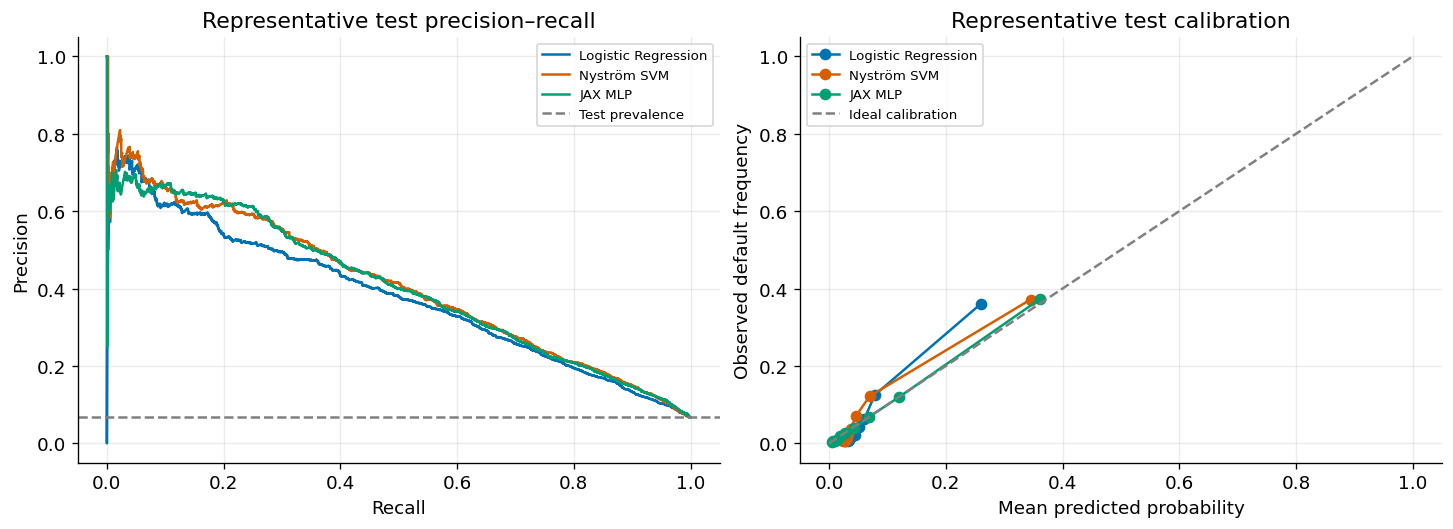

In [11]:
def threshold_counts(labels, probabilities, thresholds):
    order = np.argsort(probabilities)
    p, labels_sorted = np.asarray(probabilities)[order], np.asarray(labels, int)[order]
    cuts = np.searchsorted(p, thresholds, side='left')
    fn = np.r_[0, np.cumsum(labels_sorted)][cuts]
    fp = len(labels)-cuts-(labels_sorted.sum()-fn)
    tp, tn = labels_sorted.sum()-fn, len(labels)-labels_sorted.sum()-fp
    return tn, fp, fn, tp


def select_thresholds(labels, probabilities):
    policies, traces = {}, {}
    for name, p in probabilities.items():
        grid = np.unique(np.r_[0., p, np.nextafter(1., 2.)])
        tn, fp, fn, tp = threshold_counts(labels, p, grid)
        f1 = np.divide(2*tp, 2*tp+fp+fn, out=np.zeros(len(grid)), where=(2*tp+fp+fn)>0)
        choice = {'0.5': .5, 'F1': float(grid[np.flatnonzero(f1 == f1.max())[-1]])}
        trace = pd.DataFrame({'Threshold': grid})
        for ratio in COST_RATIOS:
            costs = ratio*fn+fp
            choice[f'Cost {ratio}:1'] = float(grid[np.flatnonzero(costs == costs.min())[-1]])
            trace[f'Cost {ratio}:1'] = costs/len(labels)*1000
        policies[name], traces[name] = choice, trace
    return policies, traces

validation_probabilities = {'Logistic Regression': lr_val, 'Nyström SVM': nys_val, 'JAX MLP': mlp_val}
frozen_policies, threshold_traces = select_thresholds(yv, validation_probabilities)
(ARTIFACTS / 'frozen_policies.json').write_text(json.dumps(frozen_policies, indent=2))
models_frozen = True

selected_configurations = pd.DataFrame([
    {'Model': 'Logistic Regression', 'Selected configuration': f"lambda={lr['lambda']:g}",
     'Validation AP': average_precision_score(yv, lr_val), 'Fit iterations / best epoch': lr['iterations']},
    {'Model': 'Nyström SVM', 'Selected configuration':
     f'm={nys.n_components}, s={bandwidth_scale:g}, lambda={svm_lam:g}',
     'Validation AP': average_precision_score(yv, nys_val), 'Fit iterations / best epoch': svm['iterations']},
    {'Model': 'JAX MLP', 'Selected configuration':
     f"{mlp_selected['Hidden widths']}, lr={mlp.learning_rate:g}, lambda={mlp.lam:g}",
     'Validation AP': average_precision_score(yv, mlp_val), 'Fit iterations / best epoch': mlp.best_epoch_}
]).set_index('Model')
save_table(selected_configurations, 'selected_configurations', show=True)

# No test features or labels are passed to search, calibration or threshold selection.
T = transform_features(X_test)
test_probabilities = {'Logistic Regression': expit(linear_score(lr, T)),
                      'Nyström SVM': svm_probability(linear_score(svm, nys.transform(T))),
                      'JAX MLP': mlp.predict_probability(T)}
test_results = pd.DataFrame({name: probability_metrics(y_test, p)
                             for name, p in test_probabilities.items()}).T
save_table(test_results, 'final_test_metrics')
timing = pd.DataFrame({'Selected classifier fit (s)': [lr['seconds'], svm['seconds'], mlp.seconds_],
                       'Selection workflow (s)': [lr_total_seconds, nys_total_seconds, mlp_total_seconds]},
                      index=list(test_probabilities))
save_table(timing, 'timings')
fig, axes = plt.subplots(1, 2, figsize=(12, 4.3), layout='constrained')
for name, p in test_probabilities.items():
    precision, recall, _ = precision_recall_curve(y_test, p)
    axes[0].plot(recall, precision, label=name, color=MODEL_COLORS[name])
    observed, predicted = calibration_curve(y_test, p, n_bins=10, strategy='quantile')
    axes[1].plot(predicted, observed, 'o-', label=name, color=MODEL_COLORS[name])
axes[0].axhline(y_test.mean(), color='.5', linestyle='--', label='Test prevalence')
axes[0].set(xlabel='Recall', ylabel='Precision', title='Representative test precision–recall')
axes[1].plot([0, 1], [0, 1], '--', color='.5', label='Ideal calibration')
axes[1].set(xlabel='Mean predicted probability', ylabel='Observed default frequency',
            title='Representative test calibration')
for ax in axes:
    ax.legend(fontsize=8)
publish(fig, '09_final_comparison')


## 7. Choosing a threshold from misclassification costs
Predict default when $p\geq t$. A **false negative (FN)** misses an actual default;
a **false positive (FP)** flags a non-defaulting borrower. Lowering the threshold
usually detects more defaults while flagging more non-defaults.

For constant costs and zero cost for correct classifications,
$$C(t)=c_{FN}FN(t)+c_{FP}FP(t).$$
For a calibrated probability $p$, predicting default has expected cost $c_{FP}(1-p)$;
predicting non-default has expected cost $c_{FN}p$. Thus the theoretical rule is
$$t^*=\frac{c_{FP}}{c_{FP}+c_{FN}}.$$
This gives $1/6$ for 5:1 and $1/11$ for 10:1. It assumes calibrated probabilities,
constant costs and a representative population. Our cost ratios are illustrative
units, not measured financial losses. The empirical validation optimum may differ
because of finite samples and imperfect calibration.

The validation curves below generated the already frozen thresholds; dots mark
their selected cost minima. We evaluate
0.5, validation-selected F1, validation-selected cost, and the theoretical rule on
test data without retuning. F1 balances precision and recall but does not encode
these explicit costs. Always-negative and always-positive policies give reference costs.

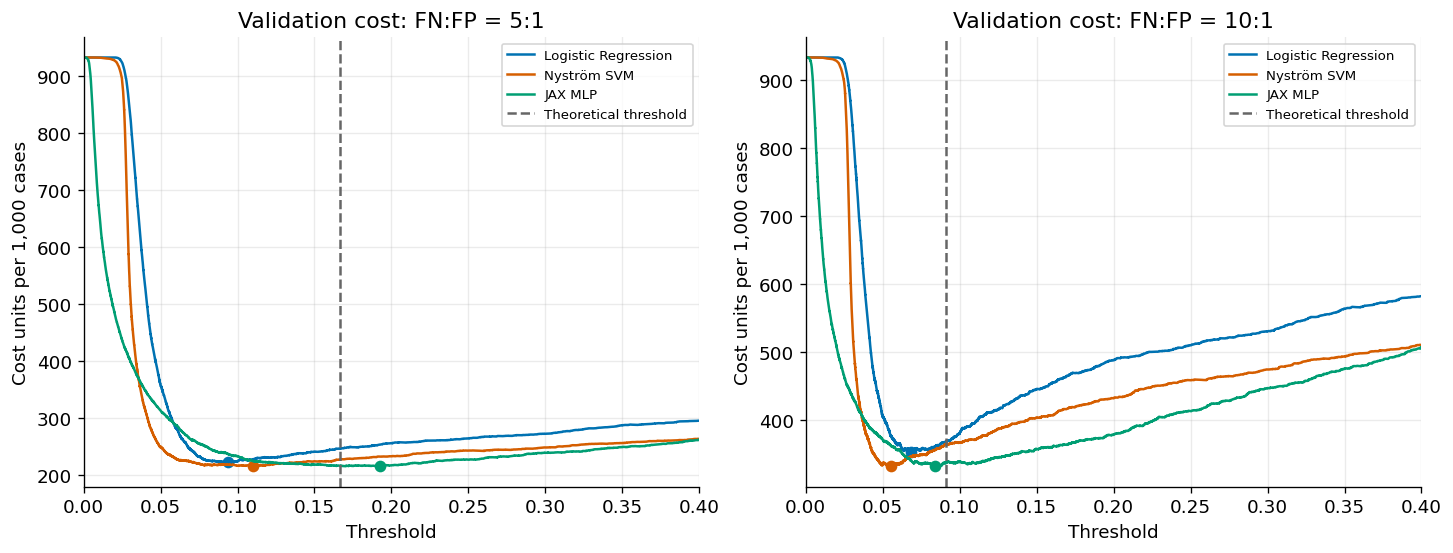

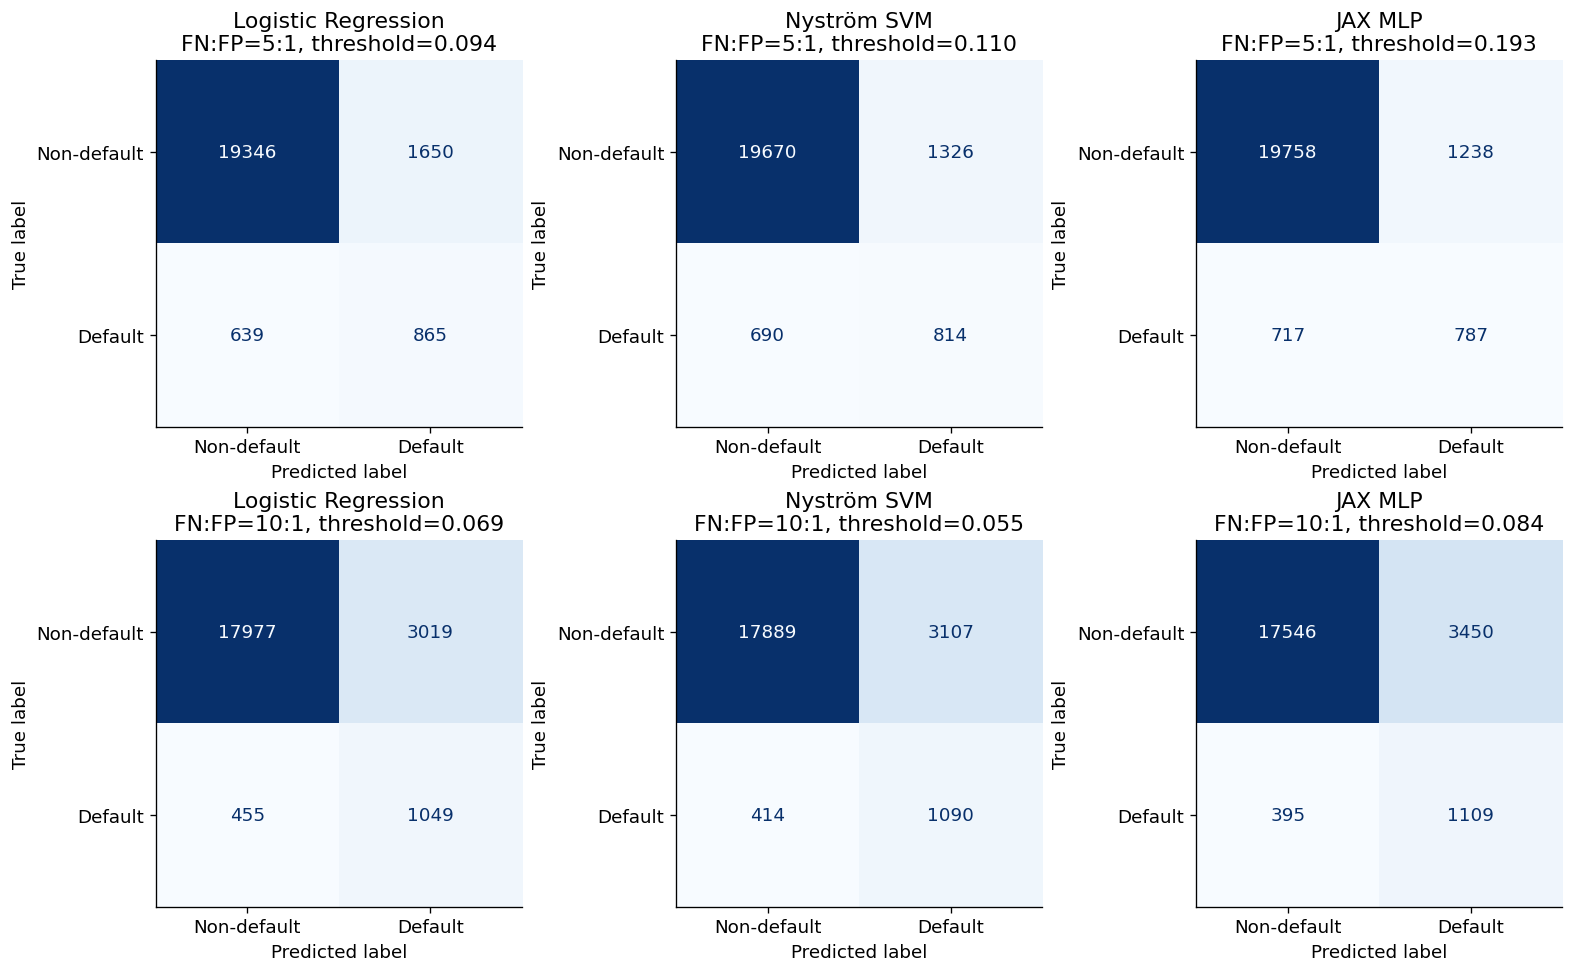

**Decision interpretation.** Increasing the assumed cost of a missed default lowers the theoretical threshold and puts more weight on recall. Compare the frozen policies using both their error counts and cost per 1,000 cases. A policy may perform worse on test than on validation.

In [12]:
assert models_frozen
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), layout='constrained')
for ax, ratio in zip(axes, COST_RATIOS):
    for name, trace in threshold_traces.items():
        ax.plot(trace.Threshold, trace[f'Cost {ratio}:1'], label=name, color=MODEL_COLORS[name])
        t = frozen_policies[name][f'Cost {ratio}:1']
        _, fp, fn, _ = threshold_counts(yv, validation_probabilities[name], np.array([t]))
        ax.plot(t, (ratio*fn[0]+fp[0])/len(yv)*1000, 'o', color=MODEL_COLORS[name])
    ax.axvline(1/(1+ratio), color='.4', linestyle='--', label='Theoretical threshold')
    ax.set(xlabel='Threshold', ylabel='Cost units per 1,000 cases', title=f'Validation cost: FN:FP = {ratio}:1', xlim=(0, .4))
    ax.legend(fontsize=8)
publish(fig, '10_threshold_costs')
save_table(pd.DataFrame(frozen_policies).T, 'selected_thresholds')

rows = []
for name, p in test_probabilities.items():
    for ratio in COST_RATIOS:
        policies = {'0.5': .5, 'Validation F1': frozen_policies[name]['F1'],
                    'Validation cost': frozen_policies[name][f'Cost {ratio}:1'],
                    'Theoretical': 1/(1+ratio), 'Always negative': np.nextafter(1., 2.), 'Always positive': 0.}
        for label, t in policies.items():
            tn, fp, fn, tp = confusion_matrix(y_test, p >= t, labels=[0, 1]).ravel()
            rows.append({'Model': name, 'FN:FP cost': f'{ratio}:1', 'Policy': label, 'Threshold': t,
                'TN': tn, 'FP': fp, 'FN': fn, 'TP': tp, 'Precision': tp/(tp+fp) if tp+fp else 0.,
                'Recall': tp/(tp+fn), 'F1': 2*tp/(2*tp+fp+fn),
                'Cost / 1000': (ratio*fn+fp)/len(y_test)*1000})
cost_results = pd.DataFrame(rows)
cost_results.to_csv(ARTIFACTS / 'final_test_costs.csv', index=False)
fig, axes = plt.subplots(2, 3, figsize=(13, 8), layout='constrained')
for row, ratio in enumerate(COST_RATIOS):
    for ax, (name, p) in zip(axes[row], test_probabilities.items()):
        t = frozen_policies[name][f'Cost {ratio}:1']
        ConfusionMatrixDisplay.from_predictions(y_test, p >= t, labels=[0, 1],
            display_labels=['Non-default', 'Default'], ax=ax, colorbar=False, cmap='Blues', values_format='d')
        ax.set_title(f'{name}\nFN:FP={ratio}:1, threshold={t:.3f}')
        ax.grid(False)
publish(fig, '11_cost_confusion_matrices')
display(Markdown('**Decision interpretation.** Increasing the assumed cost of a missed default lowers '
    'the theoretical threshold and puts more weight on recall. Compare the frozen policies using both '
    'their error counts and cost per 1,000 cases. A policy may perform worse on test than on validation.'))


### Five-seed reproducibility: combined pipeline sensitivity
Repeat seeds **42, 52, 62, 72, 82**, with a new stratified split, training-only
preprocessing, landmark draw and MLP initialization/shuffle in each run. The same
bounded grids are searched within each run's Train/Validation data; transferring
seed 42's chosen parameters would let some later test rows influence selection.
No test score chooses a model, seed, grid or threshold. Seed 42 is reused, not refitted.

Report **mean ± sample standard deviation** of out-of-sample AP, ROC-AUC, Brier
and empirical expected cost per 1,000 cases: $1000(rFN+FP)/n$ for $r=5,10$.
Thresholds minimize each run's validation cost. These overlapping holdouts measure
combined pipeline sensitivity, not independent replicates or separate variance
components. AP uses `average_precision_score`, rather than trapezoidal PR-AUC.


In [13]:
def record_seed_metrics(seed, labels, probabilities, policies, settings):
    records = []
    for name, p in probabilities.items():
        row = {'Seed': seed, 'Split seed': seed, 'Initialization / landmark seed': seed,
               'Model': name, 'Test rows': len(labels), 'Test defaults': int(np.sum(labels)),
               **probability_metrics(labels, p), **settings[name]}
        for ratio in COST_RATIOS:
            threshold = policies[name][f'Cost {ratio}:1']
            tn, fp, fn, tp = threshold_counts(labels, p, np.array([threshold]))
            row.update({f'Threshold {ratio}:1': threshold, f'FP {ratio}:1': int(fp[0]),
                        f'FN {ratio}:1': int(fn[0]),
                        f'Cost {ratio}:1 / 1000': float(1000*(ratio*fn[0]+fp[0])/len(labels))})
        records.append(row)
    return records

def setting_records(logistic, mapping, margin, scale, network, network_row):
    return {'Logistic Regression': {'lambda': logistic['lambda'],
                                    'Iterations / best epoch': logistic['iterations']},
            'Nyström SVM': {'lambda': margin['lambda'], 'Landmarks': mapping.n_components,
                            'Bandwidth scale': scale, 'gamma': mapping.gamma_,
                            'Jitter': mapping.jitter_, 'Iterations / best epoch': margin['iterations']},
            'JAX MLP': {'lambda': network.lam, 'Learning rate': network.learning_rate,
                        'Architecture': network_row['Hidden widths'],
                        'Iterations / best epoch': network.best_epoch_}}

def repeat_pipeline(seed):
    raw_train, raw_valid, raw_test, train_labels, valid_labels, test_labels = split_raw_data(seed)
    # Every learned preprocessing value is local to this seed's training rows.
    engineered_train, seed_medians = engineer_features(raw_train)
    engineered_valid, _ = engineer_features(raw_valid, seed_medians)
    seed_scaler = StandardScaler().fit(engineered_train)
    train, valid = seed_scaler.transform(engineered_train), seed_scaler.transform(engineered_valid)
    train_y, valid_y = train_labels.to_numpy(float), valid_labels.to_numpy(float)
    logistic, _, _, _ = search_logistic(train, valid, train_y, valid_y, seed)
    mapping, margin, scale, _, _ = search_nystrom(train, valid, train_y, valid_y, seed)
    calibrator = fit_sigmoid(linear_score(margin, mapping.transform(valid)), valid_y, seed)
    _, network, network_row, _, _ = search_mlp(train, valid, train_y, valid_y, seed)
    valid_predictions = {
        'Logistic Regression': expit(linear_score(logistic, valid)),
        'Nyström SVM': calibrated_svm_probability(linear_score(margin, mapping.transform(valid)), calibrator),
        'JAX MLP': network.predict_probability(valid)}
    policies, _ = select_thresholds(valid_y, valid_predictions)
    settings = setting_records(logistic, mapping, margin, scale, network, network_row)
    (ARTIFACTS / f'frozen_policies_seed_{seed}.json').write_text(json.dumps(policies, indent=2))
    (ARTIFACTS / f'selected_settings_seed_{seed}.json').write_text(json.dumps(settings, indent=2))
    # Only after all choices are frozen do we transform and predict this test set.
    engineered_test, _ = engineer_features(raw_test, seed_medians)
    test = seed_scaler.transform(engineered_test)
    predictions = {
        'Logistic Regression': expit(linear_score(logistic, test)),
        'Nyström SVM': calibrated_svm_probability(linear_score(margin, mapping.transform(test)), calibrator),
        'JAX MLP': network.predict_probability(test)}
    pd.DataFrame({'Row ID': raw_test.index, 'Label': test_labels.to_numpy(), **predictions}).to_csv(
        ARTIFACTS / f'test_predictions_seed_{seed}.csv', index=False)
    return record_seed_metrics(seed, test_labels.to_numpy(), predictions, policies, settings)

primary_settings = setting_records(lr, nys, svm, bandwidth_scale, mlp, mlp_selected)
(ARTIFACTS / f'frozen_policies_seed_{SEED}.json').write_text(json.dumps(frozen_policies, indent=2))
(ARTIFACTS / f'selected_settings_seed_{SEED}.json').write_text(json.dumps(primary_settings, indent=2))
pd.DataFrame({'Row ID': X_test.index, 'Label': y_test.to_numpy(), **test_probabilities}).to_csv(
    ARTIFACTS / f'test_predictions_seed_{SEED}.csv', index=False)
seed_records = record_seed_metrics(SEED, y_test.to_numpy(), test_probabilities, frozen_policies, primary_settings)
pd.DataFrame(seed_records).to_csv(ARTIFACTS / 'five_seed_study.csv', index=False)
for study_seed in STUDY_SEEDS:
    if study_seed == SEED:
        continue
    seed_records.extend(repeat_pipeline(study_seed))
    pd.DataFrame(seed_records).to_csv(ARTIFACTS / 'five_seed_study.csv', index=False)

five_seed_results = pd.DataFrame(seed_records)
assert not five_seed_results.duplicated(['Seed', 'Model']).any()
assert len(five_seed_results) == len(STUDY_SEEDS)*3
metric_names = ['AP', 'ROC-AUC', 'Brier', 'Cost 5:1 / 1000', 'Cost 10:1 / 1000']
assert np.isfinite(five_seed_results[metric_names].to_numpy()).all()
grouped = five_seed_results.groupby('Model', sort=False)[metric_names]
means, stds = grouped.mean(), grouped.std(ddof=1)
summary = pd.DataFrame(index=means.index)
for metric in metric_names:
    decimals = 2 if metric.startswith('Cost') else 4
    summary[metric] = [f'{mean:.{decimals}f} ± {std:.{decimals}f}'
                       for mean, std in zip(means[metric], stds[metric])]
save_table(summary, 'five_seed_summary', show=True)
grouped.agg(['mean', 'std']).to_csv(ARTIFACTS / 'five_seed_summary_numeric.csv')
flush_solver_stats()

manifest = {'representative_seed': SEED, 'study_seeds': list(STUDY_SEEDS),
            'split': {'train': 105000, 'validation': 22500, 'test': 22500},
            'dataset_sha256': hashlib.sha256(csv_path.read_bytes()).hexdigest(),
            'versions': versions, 'jax_x64_enabled': bool(jax.config.x64_enabled),
            'grids': {'logistic_lambda': LR_GRID, 'landmarks': NYSTROM_M_GRID,
                      'bandwidth_scale': NYSTROM_SCALE_GRID, 'svm_lambda': SVM_L2_GRID,
                      'mlp_learning_rate': MLP_RATE_GRID, 'mlp_lambda': MLP_L2_GRID,
                      'mlp_architectures': architectures},
            'mlp_batch_size': BATCH_SIZE, 'mlp_max_epochs': MAX_EPOCHS, 'mlp_patience': PATIENCE,
            'selection': 'Repeated separately on Train/Validation for every split seed',
            'validation_reuse': 'hyperparameters, early stopping, SVM calibration, thresholds',
            'test_used_for_selection': False, 'ensemble': False,
            'seconds': perf_counter()-run_started}
(ARTIFACTS / 'run_manifest.json').write_text(json.dumps(manifest, indent=2))
print(f'Five-seed study complete. Full grids and diagnostics: {ARTIFACTS.resolve()}')


,AP,ROC-AUC,Brier,Cost 5:1 / 1000,Cost 10:1 / 1000
Model,,,,,
Logistic Regression,0.3774 ± 0.0047,0.8529 ± 0.0042,0.0520 ± 0.0002,218.92 ± 2.19,349.41 ± 8.74
Nyström SVM,0.3983 ± 0.0081,0.8634 ± 0.0054,0.0504 ± 0.0003,214.45 ± 2.06,333.41 ± 8.21
JAX MLP,0.4003 ± 0.0036,0.8637 ± 0.0054,0.0490 ± 0.0003,213.67 ± 2.11,335.17 ± 6.47


Five-seed study complete. Full grids and diagnostics: /Users/leonardopelorosso/Documents/HPC_25_26/sem_1/NAML/PredictingCreditDefault/artifacts_focused


**Limits and references.** Five repeated holdouts jointly vary data, initialization
and landmarks; they do not isolate these effects. Validation is reused for several
choices. Mean ± SD is descriptive because test sets overlap. AP and empirical
cost differences do not establish statistical superiority. Stable arithmetic and
small gradients do not guarantee good prediction. Feature engineering and cost
ratios remain modeling assumptions. Previously inspected test results make this
an exploratory numerical study, not a new confirmatory benchmark.

Williams and Seeger (2001), *Using the Nyström Method to Speed Up Kernel Machines*;
Kingma and Ba (2015), *Adam: A Method for Stochastic Optimization*;
Platt (1999), *Probabilistic Outputs for Support Vector Machines and Comparisons to
Regularized Likelihood Methods*. 
